# NB09 -- CPG-Net: Contextual Policy Gating Network

## A Novel Architecture for Continual Learning in Shared Autonomy

### Motivation

Previous experiments showed that **replay-based CL methods hit a ceiling** in our shared autonomy domain:
- DER++ (best existing replay method): ACC = 0.6120
- The fundamental issue: a **single shared-weight MLP** forces all participants' policies into the same weight space

### CPG-Net Architecture

Combines **architectural adaptation** with **replay** and **regularization**:

1. **Shared Backbone**: All tasks share the same feature extractor (enables positive transfer)
2. **FiLM Conditioning**: Per-task Feature-wise Linear Modulation (`h = γ·h + β`) that adapts features without reducing capacity
3. **Task-Aware Replay**: DER++-style replay buffer that routes each replayed sample through its **original task's FiLM parameters**
4. **Importance Regularization**: Fisher-based importance on shared backbone, accumulated across tasks
5. **Progressive FiLM Freezing**: After training on task $t$, freeze $γ_t$ and $β_t$ to prevent retroactive modification
6. **Retroactive Importance Boosting**: Boost importance of early-task weights after later tasks
7. **FiLM Warm-Start**: Initialize new task FiLM from the most similar previous task
8. **Adaptive Replay Weighting**: Scale replay loss by per-task R² gap
9. **Multi-Head Output**: Per-task output heads blended with shared head

### Final Results

| Strategy | ACC | Forgetting | BWT | FWT |
|---|---|---|---|---|
| **CPG-Net (ours)** | **0.6895** | **0.0168** | -0.017 | +0.129 |
| Joint Training | 0.6442 | — | — | — |
| DER++ | 0.6120 | 0.0439 | -0.044 | +0.082 |
| Online EWC | 0.4152 | 0.0832 | -0.083 | +0.044 |
| A-GEM | 0.4196 | 0.0805 | -0.081 | +0.013 |

### Metrics

- **ACC** = Average Accuracy (mean R² on all tasks after final training)
- **F** = Forgetting (max previous accuracy minus final, averaged)
- **BWT** = Backward Transfer
- **FWT** = Forward Transfer
- **Memory** = Extra memory usage (MB)
- **Time** = Training time (seconds)

In [1]:
import os, sys, abc, copy, json, logging, random, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(message)s')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} -- device: {DEVICE}')
if DEVICE == 'cuda': print(f'  GPU: {torch.cuda.get_device_name()}')

PROJECT_ROOT = "/home/g0amer/Desktop/thesis/phd_project/thesis_project"
HARMONIC_DIR = f'{PROJECT_ROOT}/data/processed/harmonic'
RESULTS_DIR  = f'{PROJECT_ROOT}/experiments/exp07_cpg_net'
os.makedirs(RESULTS_DIR, exist_ok=True)

participants = sorted([d for d in os.listdir(HARMONIC_DIR)
                       if os.path.isdir(os.path.join(HARMONIC_DIR, d)) and d.startswith('p')])
print(f'Available participants: {len(participants)} -- {participants}')
print(f'Results: {RESULTS_DIR}')


PyTorch 2.10.0+cu128 -- device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Available participants: 24 -- ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109', 'p110', 'p111', 'p112', 'p113', 'p114', 'p115', 'p116', 'p117', 'p118', 'p119', 'p120', 'p121', 'p122', 'p123']
Results: /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp07_cpg_net


In [2]:
# ================================================================
# Continual Learning Metrics: ACC, F, BWT, FWT, Memory, Time
# (Identical to NB08 for fair comparison)
# ================================================================

@dataclass
class TaskResult:
    task_id: int; loss: float; mse: float; mae: float; r2: float
    n_samples: int = 0
    per_dim_mse: list = field(default_factory=list)
    ss_res: float = 0.0
    ss_tot: float = 0.0


class CLMetrics:
    # Tracks the R2 accuracy matrix a[i][j] = R2 on task j after training up to task i
    def __init__(self):
        self.R = []       # accuracy matrix (R2): R[i][j]
        self.MSE = []     # mse matrix
        self.per_dim = [] # per-dim MSE matrix
        self._last_results = []
        self.task_names = []
        self._random_baselines = []  # b_j for FWT

    def set_random_baselines(self, baselines):
        self._random_baselines = baselines

    def record(self, trained_up_to, task_results):
        r2_row = [r.r2 for r in task_results]
        mse_row = [r.mse for r in task_results]
        pdim_row = [r.per_dim_mse for r in task_results]
        while len(self.R) <= trained_up_to:
            self.R.append([])
            self.MSE.append([])
            self.per_dim.append([])
        self.R[trained_up_to] = r2_row
        self.MSE[trained_up_to] = mse_row
        self.per_dim[trained_up_to] = pdim_row
        self._last_results = task_results

    @property
    def T(self):
        return len(self.R)

    @property
    def ACC(self):
        if self.T == 0: return float('nan')
        last = self.R[-1]
        return float(np.mean(last)) if last else float('nan')

    @property
    def forgetting(self):
        T = self.T
        if T < 2: return 0.0
        fgt_sum = 0.0
        for j in range(T - 1):
            max_prev = max(self.R[l][j] for l in range(T - 1)
                          if j < len(self.R[l]))
            final = self.R[T - 1][j] if j < len(self.R[T - 1]) else 0.0
            fgt_sum += max(0.0, max_prev - final)
        return fgt_sum / (T - 1)

    @property
    def BWT(self):
        T = self.T
        if T < 2: return 0.0
        bwt = 0.0
        cnt = 0
        for j in range(T - 1):
            if j < len(self.R[T - 1]) and j < len(self.R[j]):
                bwt += self.R[T - 1][j] - self.R[j][j]
                cnt += 1
        return bwt / cnt if cnt > 0 else 0.0

    @property
    def FWT(self):
        T = self.T
        if T < 2: return 0.0
        fwt = 0.0
        cnt = 0
        for j in range(1, T):
            if j < len(self.R[j - 1]):
                b_j = self._random_baselines[j] if j < len(self._random_baselines) else 0.0
                fwt += self.R[j - 1][j] - b_j
                cnt += 1
        return fwt / cnt if cnt > 0 else 0.0

    @property
    def overall_r2(self):
        if not self._last_results: return float('nan')
        ss_res = sum(r.ss_res for r in self._last_results)
        ss_tot = sum(r.ss_tot for r in self._last_results)
        return 1 - ss_res / max(ss_tot, 1e-8)

    def summary_dict(self):
        return {
            'ACC': self.ACC, 'F': self.forgetting,
            'BWT': self.BWT, 'FWT': self.FWT,
            'overall_r2': self.overall_r2,
            'r2_matrix': self.R, 'mse_matrix': self.MSE,
            'per_dim_matrix': self.per_dim,
            'task_names': self.task_names,
        }


@dataclass
class TaskData:
    task_id: int; participant_id: str
    obs_train: torch.Tensor; act_train: torch.Tensor
    obs_val: torch.Tensor; act_val: torch.Tensor
    obs_test: torch.Tensor; act_test: torch.Tensor

    @property
    def n_train(self): return self.obs_train.shape[0]
    @property
    def n_val(self): return self.obs_val.shape[0]
    @property
    def n_test(self): return self.obs_test.shape[0]
    def train_loader(self, bs=256):
        return DataLoader(TensorDataset(self.obs_train, self.act_train), batch_size=bs, shuffle=True)
    def val_loader(self, bs=512):
        return DataLoader(TensorDataset(self.obs_val, self.act_val), batch_size=bs)
    def test_loader(self, bs=512):
        return DataLoader(TensorDataset(self.obs_test, self.act_test), batch_size=bs)

print('CLMetrics (ACC, F, BWT, FWT) & TaskData defined')


CLMetrics (ACC, F, BWT, FWT) & TaskData defined


In [3]:
# ================================================================
# Models & CL Strategies (Baselines + CPG-Net)
# ================================================================

# ---------- Standard MLP (for baselines) ----------
class MLPPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(256,256), dropout=0.1):
        super().__init__()
        layers = []
        d = obs_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(d, act_dim)
        self.obs_dim, self.act_dim = obs_dim, act_dim
        self._feat_dim = d

    def forward(self, x):
        return self.head(self.backbone(x))

    def forward_with_features(self, x):
        feat = self.backbone(x)
        return self.head(feat), feat


# ================================================================
# CPG-Net: Contextual Policy Gating Network
# ================================================================
#
# A hybrid continual learning architecture that combines three
# complementary mechanisms to prevent catastrophic forgetting:
#
# Architecture:
#   Input -> [Shared Layer 1] -> ReLU -> FiLM_1(task) -> Drop
#         -> [Shared Layer 2] -> ReLU -> FiLM_2(task) -> Drop
#         -> [Head] -> Output
#
# where FiLM(task):  h = gamma_task * h + beta_task   (Feature-wise Linear Modulation)
#
# Key architectural features:
#   1. FiLM Conditioning: per-task feature modulation (scale + shift) that
#      adapts shared representations without reducing capacity. Initialized
#      as identity (gamma=1, beta=0) so new tasks start from the shared repr.
#   2. Task-Aware Replay: DER++-style replay buffer that routes each replayed
#      sample through its original task's FiLM parameters, preserving correct
#      feature modulation during replay.
#   3. Importance Regularization: Fisher-based importance weighting on shared
#      backbone parameters, accumulated online across tasks to protect weights
#      critical to previously learned tasks.
#   4. Progressive FiLM Freezing: after training on task t, the task-specific
#      FiLM params (gamma_t, beta_t) are frozen to prevent retroactive modification.
#   5. Parameters registered via nn.ParameterDict for proper state_dict
#      save/restore compatibility with early stopping.

class CPGNet(nn.Module):
    # CPG-Net backbone with per-task FiLM conditioning layers
    def __init__(self, obs_dim, act_dim, hidden=(256, 256), dropout=0.1, max_tasks=20):
        super().__init__()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.hidden_dims = list(hidden)
        self.max_tasks = max_tasks
        self._n_layers = len(hidden)

        # Shared backbone layers
        self.layers = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        d = obs_dim
        for h in hidden:
            self.layers.append(nn.Linear(d, h))
            self.dropouts.append(nn.Dropout(dropout))
            d = h

        # Shared output head
        self.head = nn.Linear(d, act_dim)

        # Per-task FiLM parameters (properly registered!)
        # Keys: "t{task_id}_l{layer}_gamma", "t{task_id}_l{layer}_beta"
        self.film_params = nn.ParameterDict()
        self._frozen_tasks = set()
        self._registered_tasks = set()

    def register_task(self, task_id):
        if task_id in self._registered_tasks:
            return
        # Detect device from existing parameters
        device = next(self.parameters()).device
        for l, h in enumerate(self.hidden_dims):
            # gamma=1, beta=0 => identity transform initially
            self.film_params[f't{task_id}_l{l}_gamma'] = nn.Parameter(torch.ones(h, device=device))
            self.film_params[f't{task_id}_l{l}_beta'] = nn.Parameter(torch.zeros(h, device=device))
        self._registered_tasks.add(task_id)

    def freeze_task(self, task_id):
        if task_id in self._frozen_tasks:
            return
        for l in range(self._n_layers):
            gk = f't{task_id}_l{l}_gamma'
            bk = f't{task_id}_l{l}_beta'
            if gk in self.film_params:
                self.film_params[gk].requires_grad = False
                self.film_params[bk].requires_grad = False
        self._frozen_tasks.add(task_id)

    def get_film_params(self, task_id):
        # Return trainable FiLM parameters for this task
        params = []
        for l in range(self._n_layers):
            gk = f't{task_id}_l{l}_gamma'
            bk = f't{task_id}_l{l}_beta'
            if gk in self.film_params and self.film_params[gk].requires_grad:
                params.append(self.film_params[gk])
                params.append(self.film_params[bk])
        return params

    def forward(self, x, task_id=0):
        h = x
        for i, (layer, drop) in enumerate(zip(self.layers, self.dropouts)):
            h = F.relu(layer(h))
            # Apply FiLM conditioning if task is registered
            gk = f't{task_id}_l{i}_gamma'
            bk = f't{task_id}_l{i}_beta'
            if gk in self.film_params:
                gamma = self.film_params[gk]
                beta = self.film_params[bk]
                h = gamma * h + beta  # FiLM: scale + shift (preserves capacity)
            h = drop(h)
        return self.head(h)


# ================================================================
# Task-Aware Replay Buffer (stores task_id with each sample)
# ================================================================

class TaskAwareReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.obs, self.act, self.logits, self.task_ids = [], [], [], []
        self._n = 0

    def __len__(self): return len(self.obs)

    def add(self, obs, act, logits, task_id):
        for i in range(obs.size(0)):
            self._n += 1
            if len(self.obs) < self.capacity:
                self.obs.append(obs[i].cpu())
                self.act.append(act[i].cpu())
                self.logits.append(logits[i].cpu())
                self.task_ids.append(task_id)
            else:
                j = random.randint(0, self._n - 1)
                if j < self.capacity:
                    self.obs[j] = obs[i].cpu()
                    self.act[j] = act[i].cpu()
                    self.logits[j] = logits[i].cpu()
                    self.task_ids[j] = task_id

    def sample(self, n):
        n = min(n, len(self.obs))
        idx = random.sample(range(len(self.obs)), n)
        return (torch.stack([self.obs[i] for i in idx]),
                torch.stack([self.act[i] for i in idx]),
                torch.stack([self.logits[i] for i in idx]),
                torch.tensor([self.task_ids[i] for i in idx]))

    def memory_mb(self):
        if len(self.obs) == 0: return 0.0
        per_sample = self.obs[0].nelement() + self.act[0].nelement() + self.logits[0].nelement()
        return len(self.obs) * per_sample * 4 / (1024**2)


# ================================================================
# ContinualLearner base class
# ================================================================

class ContinualLearner(abc.ABC):
    def __init__(self, model, lr=1e-3, weight_decay=0., device='cpu'):
        self.model = model.to(device); self.device = device; self.lr = lr
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self._current_task = -1

    @abc.abstractmethod
    def on_task_start(self, task_id, train_loader): ...
    @abc.abstractmethod
    def compute_loss(self, obs, act, task_id): ...
    @abc.abstractmethod
    def on_task_end(self, task_id, train_loader): ...

    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        self.model.train()
        best_val, best_state, no_improve = float('inf'), None, 0
        for epoch in range(epochs):
            eloss, nb = 0., 0
            for batch in train_loader:
                obs, act = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                loss = self.compute_loss(obs, act, task_id)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                eloss += loss.item(); nb += 1
            if val_loader is not None:
                vl = self._eval_loss(val_loader, task_id)
                if vl < best_val:
                    best_val = vl; best_state = copy.deepcopy(self.model.state_dict()); no_improve = 0
                else: no_improve += 1
                if no_improve >= patience: break
        if best_state is not None: self.model.load_state_dict(best_state)
        self.on_task_end(task_id, train_loader)

    def _eval_loss(self, loader, task_id=0):
        self.model.eval()
        tot, n = 0., 0
        with torch.no_grad():
            for b in loader:
                o, a = b[0].to(self.device), b[1].to(self.device)
                if isinstance(self.model, CPGNet):
                    pred = self.model(o, task_id=task_id)
                else:
                    pred = self.model(o)
                tot += F.mse_loss(pred, a).item() * o.size(0); n += o.size(0)
        self.model.train()
        return tot / max(n, 1)

    def evaluate_task(self, test_loader, task_id):
        self.model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for b in test_loader:
                o, a = b[0].to(self.device), b[1].to(self.device)
                if isinstance(self.model, CPGNet):
                    preds.append(self.model(o, task_id=task_id).cpu())
                else:
                    preds.append(self.model(o).cpu())
                tgts.append(a.cpu())
        p, t = torch.cat(preds), torch.cat(tgts)
        mse = F.mse_loss(p, t).item()
        mae = (p - t).abs().mean().item()
        ss_res = ((t - p)**2).sum().item()
        ss_tot = ((t - t.mean(0))**2).sum().item()
        r2 = 1 - ss_res / max(ss_tot, 1e-8)
        per_dim = ((p - t)**2).mean(0).tolist()
        self.model.train()
        return TaskResult(task_id, mse, mse, mae, r2, len(t), per_dim, ss_res, ss_tot)


# ================================================================
# Baseline strategies (same as NB08 for fair comparison)
# ================================================================

class NaiveFineTune(ContinualLearner):
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, t): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, t, l): pass
    def memory_mb(self): return 0.0


class JointTraining(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu'):
        super().__init__(model, lr=lr, device=device)
        self._datasets = {}; self._init_state = copy.deepcopy(model.state_dict())
    def on_task_start(self, task_id, train_loader):
        all_o, all_a = [], []
        for b in train_loader: all_o.append(b[0]); all_a.append(b[1])
        self._datasets[task_id] = TensorDataset(torch.cat(all_o), torch.cat(all_a))
        self.model.load_state_dict(copy.deepcopy(self._init_state))
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
    def compute_loss(self, obs, act, t): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, t, l): pass
    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        joint_ds = ConcatDataset(list(self._datasets.values()))
        bs = train_loader.batch_size if hasattr(train_loader, 'batch_size') else 256
        joint_loader = DataLoader(joint_ds, batch_size=bs, shuffle=True)
        self.model.train()
        super().train_task(task_id, joint_loader, val_loader, epochs, patience, verbose)
    def memory_mb(self):
        total = sum(t.tensors[0].nelement() + t.tensors[1].nelement() for t in self._datasets.values())
        return total * 4 / (1024**2)


class ReplayBuffer:
    def __init__(self, capacity=10000, store_features=False):
        self.capacity = capacity
        self.store_features = store_features
        self.obs, self.act, self.logits = [], [], []
        self.features = []
        self._n = 0
    def __len__(self): return len(self.obs)
    def add(self, obs, act, logits, features=None):
        for i in range(obs.size(0)):
            self._n += 1
            if len(self.obs) < self.capacity:
                self.obs.append(obs[i].cpu())
                self.act.append(act[i].cpu())
                self.logits.append(logits[i].cpu())
                if self.store_features and features is not None:
                    self.features.append(features[i].cpu())
            else:
                j = random.randint(0, self._n - 1)
                if j < self.capacity:
                    self.obs[j] = obs[i].cpu()
                    self.act[j] = act[i].cpu()
                    self.logits[j] = logits[i].cpu()
                    if self.store_features and features is not None:
                        self.features[j] = features[i].cpu()
    def sample(self, n):
        n = min(n, len(self.obs))
        idx = random.sample(range(len(self.obs)), n)
        result = (torch.stack([self.obs[i] for i in idx]),
                  torch.stack([self.act[i] for i in idx]),
                  torch.stack([self.logits[i] for i in idx]))
        if self.store_features and self.features:
            result = result + (torch.stack([self.features[i] for i in idx]),)
        return result
    def memory_mb(self):
        if len(self.obs) == 0: return 0.0
        per_sample = self.obs[0].nelement() + self.act[0].nelement() + self.logits[0].nelement()
        if self.store_features and self.features:
            per_sample += self.features[0].nelement()
        return len(self.obs) * per_sample * 4 / (1024**2)


class DERPlusPlus(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', buffer_size=10000, alpha=0.5, beta=0.5):
        super().__init__(model, lr=lr, device=device)
        self.buffer = ReplayBuffer(buffer_size)
        self.alpha = alpha; self.beta = beta
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id):
        pred = self.model(obs); loss = F.mse_loss(pred, act)
        with torch.no_grad(): logits = self.model(obs).detach()
        self.buffer.add(obs.detach(), act.detach(), logits)
        if len(self.buffer) > 0 and task_id > 0:
            bo, ba, bl = self.buffer.sample(max(1, obs.size(0)))
            bo, ba, bl = bo.to(self.device), ba.to(self.device), bl.to(self.device)
            bp = self.model(bo)
            loss = loss + self.alpha * F.mse_loss(bp, bl) + self.beta * F.mse_loss(bp, ba)
        return loss
    def on_task_end(self, t, l): pass
    def memory_mb(self): return self.buffer.memory_mb()


class EWC(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', ewc_lambda=10000., fisher_samples=1000,
                 online=True, gamma=0.99):
        super().__init__(model, lr=lr, device=device)
        self.ewc_lambda = ewc_lambda; self.fisher_samples = fisher_samples
        self.online = online; self.gamma = gamma
        self._fishers = []; self._opt_params = []
        self._run_fisher = None; self._run_params = None
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id):
        loss = F.mse_loss(self.model(obs), act)
        if task_id == 0: return loss
        return loss + self._penalty()
    def on_task_end(self, task_id, train_loader):
        fisher = self._compute_fisher(train_loader)
        if self.online:
            if self._run_fisher is None: self._run_fisher = fisher
            else:
                for n in self._run_fisher:
                    self._run_fisher[n] = self.gamma * self._run_fisher[n] + fisher[n]
            self._run_params = {n: p.clone().detach() for n, p in self.model.named_parameters() if p.requires_grad}
        else:
            self._fishers.append(fisher)
            self._opt_params.append({n: p.clone().detach() for n, p in self.model.named_parameters() if p.requires_grad})
    def _compute_fisher(self, loader):
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters() if p.requires_grad}
        self.model.eval(); ns = 0
        for b in loader:
            o, a = b[0].to(self.device), b[1].to(self.device)
            self.model.zero_grad()
            F.mse_loss(self.model(o), a).backward()
            for n, p in self.model.named_parameters():
                if p.requires_grad and p.grad is not None:
                    fisher[n] += p.grad.data.pow(2) * o.size(0)
            ns += o.size(0)
            if ns >= self.fisher_samples: break
        for n in fisher: fisher[n] /= max(ns, 1)
        self.model.train()
        return fisher
    def _penalty(self):
        pen = torch.tensor(0., device=self.device)
        if self.online and self._run_fisher is not None:
            for n, p in self.model.named_parameters():
                if n in self._run_fisher:
                    pen += (self._run_fisher[n] * (p - self._run_params[n]).pow(2)).sum()
        else:
            for fi, op in zip(self._fishers, self._opt_params):
                for n, p in self.model.named_parameters():
                    if n in fi: pen += (fi[n] * (p - op[n]).pow(2)).sum()
        return (self.ewc_lambda / 2.) * pen
    def memory_mb(self):
        n_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        if self.online:
            return 2 * n_params * 4 / (1024**2) if self._run_fisher else 0.0
        else:
            return 2 * len(self._fishers) * n_params * 4 / (1024**2)


class AGEM(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', mem_per_task=256):
        super().__init__(model, lr=lr, device=device)
        self._mem = {}; self._cap = mem_per_task
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, task_id, train_loader):
        all_o, all_a = [], []
        for b in train_loader: all_o.append(b[0]); all_a.append(b[1])
        obs = torch.cat(all_o); act = torch.cat(all_a)
        if len(obs) > self._cap:
            idx = torch.randperm(len(obs))[:self._cap]
            obs, act = obs[idx], act[idx]
        self._mem[task_id] = (obs, act)
    def _get_ref(self):
        if not self._mem: return None, None
        return torch.cat([v[0] for v in self._mem.values()]), torch.cat([v[1] for v in self._mem.values()])
    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        self.model.train()
        best_val, best_state, no_improve = float('inf'), None, 0
        for epoch in range(epochs):
            eloss, nb = 0., 0
            for batch in train_loader:
                obs, act = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                loss = self.compute_loss(obs, act, task_id)
                loss.backward()
                if task_id > 0:
                    g = torch.cat([p.grad.data.view(-1) for p in self.model.parameters() if p.grad is not None])
                    mem_o, mem_a = self._get_ref()
                    if mem_o is not None:
                        mem_o, mem_a = mem_o.to(self.device), mem_a.to(self.device)
                        self.optimizer.zero_grad()
                        ref_loss = F.mse_loss(self.model(mem_o), mem_a)
                        ref_loss.backward()
                        g_ref = torch.cat([p.grad.data.view(-1) for p in self.model.parameters() if p.grad is not None])
                        dot = (g * g_ref).sum()
                        if dot < 0:
                            g = g - (dot / (g_ref.norm()**2 + 1e-8)) * g_ref
                        offset = 0
                        for p in self.model.parameters():
                            if p.grad is not None:
                                numel = p.grad.numel()
                                p.grad.data.copy_(g[offset:offset+numel].view_as(p.grad))
                                offset += numel
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                eloss += loss.item(); nb += 1
            if val_loader is not None:
                vl = self._eval_loss(val_loader)
                if vl < best_val:
                    best_val = vl; best_state = copy.deepcopy(self.model.state_dict()); no_improve = 0
                else: no_improve += 1
                if no_improve >= patience: break
        if best_state is not None: self.model.load_state_dict(best_state)
        self.on_task_end(task_id, train_loader)
    def memory_mb(self):
        total = sum(v[0].nelement() + v[1].nelement() for v in self._mem.values())
        return total * 4 / (1024**2)


print('All strategies defined: Naive, Joint, DER++, Online EWC, A-GEM, CPG-Net')

All strategies defined: Naive, Joint, DER++, Online EWC, A-GEM, CPG-Net


In [4]:
# Data Loading -- identical to previous experiments

JOY_COLS   = ['axes_x', 'axes_y', 'axes_z']
JPOS_COLS  = [f'mico_joint_{i}_pos' for i in range(1, 7)]
EE_COLS    = ['mico_end_effector_x', 'mico_end_effector_y', 'mico_end_effector_z']
JVEL_COLS  = [f'mico_joint_{i}_vel' for i in range(1, 7)]
OBS_COLS   = JOY_COLS + JPOS_COLS + EE_COLS
TARGET_COLS = JVEL_COLS
JOINT_POS_CLIP = 50.0

def load_participant(processed_dir, participant, val_ratio=0.15, seed=42):
    pdir = Path(processed_dir) / participant
    assert pdir.exists(), f'Not found: {pdir}'

    all_obs, all_tgt = [], []
    for trial_dir in sorted(pdir.iterdir()):
        if not trial_dir.is_dir():
            continue
        joy_path  = trial_dir / 'ada_joy.parquet'
        jpos_path = trial_dir / 'joint_positions.parquet'
        rpos_path = trial_dir / 'robot_position.parquet'
        if not all(p.exists() for p in [joy_path, jpos_path, rpos_path]):
            continue
        df_joy  = pd.read_parquet(joy_path)
        df_jpos = pd.read_parquet(jpos_path)
        df_rpos = pd.read_parquet(rpos_path)
        n = min(len(df_joy), len(df_jpos), len(df_rpos))
        if n < 10:
            continue
        for col_name in JPOS_COLS:
            if col_name in df_jpos.columns:
                mask = df_jpos[col_name].abs() > JOINT_POS_CLIP
                if mask.any():
                    median_val = df_jpos.loc[~mask, col_name].median()
                    df_jpos.loc[mask, col_name] = median_val
        obs_parts = []
        for cols, df in [(JOY_COLS, df_joy), (JPOS_COLS, df_jpos), (EE_COLS, df_rpos)]:
            available = [c for c in cols if c in df.columns]
            if len(available) != len(cols):
                break
            obs_parts.append(df[available].values[:n])
        else:
            tgt_available = [c for c in JVEL_COLS if c in df_jpos.columns]
            if len(tgt_available) != len(JVEL_COLS):
                continue
            tgt_arr = df_jpos[tgt_available].values[:n]
            obs_arr = np.concatenate(obs_parts, axis=1)
            valid = ~(np.isnan(obs_arr).any(1) | np.isnan(tgt_arr).any(1))
            obs_arr, tgt_arr = obs_arr[valid], tgt_arr[valid]
            if len(obs_arr) > 0:
                all_obs.append(obs_arr)
                all_tgt.append(tgt_arr)
            continue
        continue

    assert all_obs, f'No data for {participant}'
    obs = np.nan_to_num(np.concatenate(all_obs).astype(np.float32))
    tgt = np.nan_to_num(np.concatenate(all_tgt).astype(np.float32))

    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(obs))
    nv = int(len(obs) * val_ratio)
    nt = nv
    obs_t, tgt_t = torch.from_numpy(obs), torch.from_numpy(tgt)
    return (obs_t[idx[nt+nv:]], tgt_t[idx[nt+nv:]],
            obs_t[idx[nt:nt+nv]], tgt_t[idx[nt:nt+nv]],
            obs_t[idx[:nt]],     tgt_t[idx[:nt]])

print(f'Data loading defined (outlier clipping at |val|>{JOINT_POS_CLIP})')


Data loading defined (outlier clipping at |val|>50.0)


In [5]:
# Hyperparameters & Task Setup

SEED = 42
HIDDEN   = (256, 256)
LR       = 1e-3
DROPOUT  = 0.1
EPOCHS   = 50
PATIENCE = 10
BS       = 256

# Baseline HPs (tuned in exp02)
EWC_LAMBDA   = 10000.0
EWC_FISHER_N = 1000
OEWC_GAMMA   = 0.99
DER_BUFFER   = 10000
AGEM_MEM     = 256

# CPG-Net HPs
CPG_BUFFER_SIZE     = 10000     # replay buffer capacity
CPG_REPLAY_ALPHA    = 0.5       # replay logit loss weight
CPG_REPLAY_BETA     = 0.5       # replay target loss weight
CPG_FILM_LR         = 5e-3      # learning rate for FiLM parameters
CPG_IMPORTANCE_LAM  = 5000.     # importance regularization strength
CPG_FISHER_N        = 2000      # samples for Fisher computation

N_TASKS = 10
obs_dim = 12
act_dim = 6

def build_tasks(n_tasks, pids):
    selected = pids[:n_tasks]
    print(f'\nBuilding {n_tasks} tasks from: {selected}')
    task_list = []
    for tid, pid in enumerate(selected):
        try:
            data = load_participant(HARMONIC_DIR, pid, seed=SEED)
            td = TaskData(tid, pid, *data)
            task_list.append(td)
            print(f'  Task {tid:2d} ({pid}): train={td.n_train:5d}  val={td.n_val:4d}  test={td.n_test:4d}')
        except Exception as e:
            print(f'  SKIP {pid}: {e}')
    return task_list

def normalize_tasks(task_list):
    all_obs = torch.cat([t.obs_train for t in task_list])
    all_act = torch.cat([t.act_train for t in task_list])
    o_mean = all_obs.mean(0); o_std = all_obs.std(0).clamp(min=1e-6)
    a_mean = all_act.mean(0); a_std = all_act.std(0).clamp(min=1e-6)
    for t in task_list:
        t.obs_train = (t.obs_train - o_mean) / o_std
        t.obs_val   = (t.obs_val   - o_mean) / o_std
        t.obs_test  = (t.obs_test  - o_mean) / o_std
        t.act_train = (t.act_train - a_mean) / a_std
        t.act_val   = (t.act_val   - a_mean) / a_std
        t.act_test  = (t.act_test  - a_mean) / a_std
    return o_mean, o_std, a_mean, a_std

def make_model():
    return MLPPolicy(obs_dim, act_dim, HIDDEN, DROPOUT)

def make_cpg_model():
    return CPGNet(obs_dim, act_dim, HIDDEN, DROPOUT, max_tasks=N_TASKS)

def run_strategy(name, learner, task_list, epochs=EPOCHS, patience=PATIENCE, bs=BS, verbose=True):
    # Compute random baselines for FWT
    torch.manual_seed(SEED)
    random_baselines = []
    if isinstance(learner.model, CPGNet):
        untrained = make_cpg_model().to(DEVICE)
        # Register task 0 for untrained model to get random baseline
        for t in task_list:
            untrained.register_task(t.task_id)
    else:
        untrained = make_model().to(DEVICE)

    for t in task_list:
        untrained.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for b in t.test_loader(bs*2):
                o, a = b[0].to(DEVICE), b[1].to(DEVICE)
                if isinstance(untrained, CPGNet):
                    preds.append(untrained(o, task_id=t.task_id).cpu())
                else:
                    preds.append(untrained(o).cpu())
                tgts.append(a.cpu())
        p, tgt = torch.cat(preds), torch.cat(tgts)
        ss_res = ((tgt - p)**2).sum().item()
        ss_tot = ((tgt - tgt.mean(0))**2).sum().item()
        random_baselines.append(1 - ss_res / max(ss_tot, 1e-8))

    metrics = CLMetrics()
    metrics.task_names = [t.participant_id for t in task_list]
    metrics.set_random_baselines(random_baselines)

    t0 = time.time()
    for task in task_list:
        if verbose:
            print(f'  [{name}] Task {task.task_id}/{len(task_list)-1} ({task.participant_id})')
        learner.train_task(task.task_id, task.train_loader(bs),
                          task.val_loader(bs*2), epochs=epochs, patience=patience, verbose=False)
        results = [learner.evaluate_task(et.test_loader(bs*2), et.task_id) for et in task_list]
        metrics.record(task.task_id, results)
    elapsed = time.time() - t0

    mem = learner.memory_mb() if hasattr(learner, 'memory_mb') else 0.0

    return {
        'name': name, 'metrics': metrics, 'time': elapsed,
        'memory_mb': mem,
        'ACC': metrics.ACC, 'F': metrics.forgetting,
        'BWT': metrics.BWT, 'FWT': metrics.FWT,
        'overall_r2': metrics.overall_r2,
        'summary': metrics.summary_dict(),
    }

# Build and normalize
task_list = build_tasks(N_TASKS, participants)
norm_stats = normalize_tasks(task_list)

print(f'\nReady: {len(task_list)} tasks, {obs_dim}D --> {act_dim}D')


Building 10 tasks from: ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109']
  Task  0 (p100): train=21274  val=4558  test=4558
  Task  1 (p101): train=26797  val=5742  test=5742
  Task  2 (p102): train=33573  val=7194  test=7194
  Task  3 (p103): train=16945  val=3631  test=3631
  Task  4 (p104): train=17868  val=3828  test=3828
  Task  5 (p105): train=11065  val=2371  test=2371
  Task  6 (p106): train=31734  val=6800  test=6800
  Task  7 (p107): train=14412  val=3087  test=3087
  Task  8 (p108): train=10253  val=2196  test=2196
  Task  9 (p109): train=21081  val=4516  test=4516

Ready: 10 tasks, 12D --> 6D


---
## Run Full Comparison

All 6 strategies (5 baselines + CPG-Net) run sequentially. Each in its own cell.
Metrics: **ACC**, **F**, **BWT**, **FWT**, **Memory (MB)**, **Time (s)**

---
## CPG-Net: Architecture & Ablation Study

CPG-Net combines FiLM conditioning with four additional targeted improvements. The ablation study below measures the contribution of each:

1. **Retroactive Importance Boosting** — re-evaluate and boost backbone importance weights after future tasks arrive
2. **FiLM Warm-Start** — initialize new FiLM from the most similar prior task (cosine similarity on input stats)
3. **Adaptive Replay Weighting** — scale replay loss per-task by R² gap (more replay for forgotten tasks)
4. **Multi-Head Output** — per-task output heads blended with shared head via learned weight

In [6]:
# ================================================================
# CPG-Net: Full Architecture with All Features
# ================================================================
# Extends the base CPGNet with four additional targeted mechanisms,
# each individually toggleable for ablation study.

class CPGNetV3(CPGNet):
    """CPG-Net with Multi-Head Output and FiLM Warm-Start.
    Inherits from CPGNet so isinstance(model, CPGNet) == True
    (needed by ContinualLearner.train_task / evaluate_task).
    """
    def __init__(self, obs_dim, act_dim, hidden=(256, 256), dropout=0.1,
                 max_tasks=20, use_multi_head=True, head_blend=0.3):
        super().__init__(obs_dim, act_dim, hidden, dropout, max_tasks)
        self.use_multi_head = use_multi_head
        self.head_blend = head_blend  # weight of task head vs shared head

        # Per-task output heads
        self.task_heads = nn.ModuleDict()

        # Task input stats for warm-start similarity
        self._task_stats = {}  # task_id -> (mean, std) tensors

    def register_task(self, task_id, warm_start_from=None):
        if task_id in self._registered_tasks:
            return
        device = next(self.parameters()).device
        for l, h in enumerate(self.hidden_dims):
            if warm_start_from is not None:
                # FiLM Warm-Start: clone FiLM from nearest task
                src_gamma = self.film_params[f't{warm_start_from}_l{l}_gamma'].data.clone()
                src_beta = self.film_params[f't{warm_start_from}_l{l}_beta'].data.clone()
                self.film_params[f't{task_id}_l{l}_gamma'] = nn.Parameter(src_gamma)
                self.film_params[f't{task_id}_l{l}_beta'] = nn.Parameter(src_beta)
            else:
                # Identity init
                self.film_params[f't{task_id}_l{l}_gamma'] = nn.Parameter(torch.ones(h, device=device))
                self.film_params[f't{task_id}_l{l}_beta'] = nn.Parameter(torch.zeros(h, device=device))
        # Per-task output head
        if self.use_multi_head:
            d = self.hidden_dims[-1]
            self.task_heads[str(task_id)] = nn.Linear(d, self.act_dim).to(device)

        self._registered_tasks.add(task_id)

    def store_task_stats(self, task_id, obs_mean, obs_std):
        self._task_stats[task_id] = (obs_mean.detach().cpu(), obs_std.detach().cpu())

    def find_nearest_task(self, obs_mean, obs_std):
        """Find the most similar registered task by input statistics (cosine similarity)."""
        if not self._task_stats:
            return None
        query = torch.cat([obs_mean.cpu(), obs_std.cpu()])
        best_tid, best_sim = None, -2.0
        for tid, (m, s) in self._task_stats.items():
            ref = torch.cat([m, s])
            sim = F.cosine_similarity(query.unsqueeze(0), ref.unsqueeze(0)).item()
            if sim > best_sim:
                best_sim = sim
                best_tid = tid
        return best_tid

    def freeze_task(self, task_id):
        super().freeze_task(task_id)
        # Also freeze task head if present
        if self.use_multi_head and str(task_id) in self.task_heads:
            for p in self.task_heads[str(task_id)].parameters():
                p.requires_grad = False

    # get_film_params inherited from CPGNet (no override needed)

    def get_task_head_params(self, task_id):
        if self.use_multi_head and str(task_id) in self.task_heads:
            return [p for p in self.task_heads[str(task_id)].parameters() if p.requires_grad]
        return []

    def forward(self, x, task_id=0):
        h = x
        for i, (layer, drop) in enumerate(zip(self.layers, self.dropouts)):
            h = F.relu(layer(h))
            gk = f't{task_id}_l{i}_gamma'
            bk = f't{task_id}_l{i}_beta'
            if gk in self.film_params:
                gamma = self.film_params[gk]
                beta = self.film_params[bk]
                h = gamma * h + beta
            h = drop(h)
        shared_out = self.head(h)
        if self.use_multi_head and str(task_id) in self.task_heads:
            task_out = self.task_heads[str(task_id)](h)
            return (1 - self.head_blend) * shared_out + self.head_blend * task_out
        return shared_out


class CPGNetLearnerV3(ContinualLearner):
    """CPG-Net Learner with all targeted features toggleable."""
    def __init__(self, model, lr=1e-3, device='cpu',
                 buffer_size=10000, replay_alpha=0.5, replay_beta=0.5,
                 importance_lambda=5000., fisher_samples=2000,
                 film_lr=5e-3,
                 # Feature toggles
                 use_retro_boost=True,      # Retroactive Importance Boosting
                 use_warm_start=True,        # FiLM Warm-Start
                 use_adaptive_replay=True,   # Adaptive Replay Weighting
                 # Multi-Head is controlled by model.use_multi_head
                 ):
        super().__init__(model, lr=lr, device=device)
        self.buffer = TaskAwareReplayBuffer(buffer_size)
        self.replay_alpha = replay_alpha
        self.replay_beta = replay_beta
        self.importance_lambda = importance_lambda
        self.fisher_samples = fisher_samples
        self.film_lr = film_lr
        self._cum_importance = None
        self._anchor_params = None
        self._completed_tasks = []
        # Feature flags
        self.use_retro_boost = use_retro_boost
        self.use_warm_start = use_warm_start
        self.use_adaptive_replay = use_adaptive_replay
        # Track per-task forgetting for adaptive replay
        self._task_peak_r2 = {}   # task_id -> best R2 seen
        self._task_current_r2 = {}  # task_id -> current R2

    def on_task_start(self, task_id, train_loader):
        warm_from = None
        if self.use_warm_start and task_id > 0:
            # FiLM Warm-Start: compute input stats and find nearest task
            all_obs = []
            for b in train_loader:
                all_obs.append(b[0])
                if len(all_obs) >= 5:
                    break
            obs_sample = torch.cat(all_obs)
            obs_mean = obs_sample.mean(0).to(self.device)
            obs_std = obs_sample.std(0).clamp(min=1e-6).to(self.device)
            warm_from = self.model.find_nearest_task(obs_mean, obs_std)
            self.model.store_task_stats(task_id, obs_mean, obs_std)
        elif self.use_warm_start and task_id == 0:
            # Store stats for first task
            all_obs = []
            for b in train_loader:
                all_obs.append(b[0])
                if len(all_obs) >= 5:
                    break
            obs_sample = torch.cat(all_obs)
            obs_mean = obs_sample.mean(0).to(self.device)
            obs_std = obs_sample.std(0).clamp(min=1e-6).to(self.device)
            self.model.store_task_stats(task_id, obs_mean, obs_std)

        self.model.register_task(task_id, warm_start_from=warm_from)

        # Build optimizer: backbone at lr, FiLM + task head at film_lr
        film_params = self.model.get_film_params(task_id)
        task_head_params = self.model.get_task_head_params(task_id)
        special_params = film_params + task_head_params
        special_ids = {id(p) for p in special_params}
        backbone_params = [p for p in self.model.parameters()
                          if p.requires_grad and id(p) not in special_ids]

        param_groups = [{'params': backbone_params, 'lr': self.lr}]
        if special_params:
            param_groups.append({'params': special_params, 'lr': self.film_lr})
        self.optimizer = torch.optim.Adam(param_groups)

    def compute_loss(self, obs, act, task_id):
        pred = self.model(obs, task_id=task_id)
        loss = F.mse_loss(pred, act)

        # Store in replay buffer
        with torch.no_grad():
            logits_snap = self.model(obs, task_id=task_id).detach()
        self.buffer.add(obs.detach(), act.detach(), logits_snap, task_id)

        # Task-aware replay
        if len(self.buffer) > 0 and task_id > 0:
            n_replay = max(1, obs.size(0))

            if self.use_adaptive_replay and self._task_peak_r2:
                # Adaptive Replay: weighted sampling by forgetting severity
                bo_list, ba_list, bl_list, bt_list = self.buffer.sample(n_replay)
                bo_list = bo_list.to(self.device)
                ba_list = ba_list.to(self.device)
                bl_list = bl_list.to(self.device)

                # Compute per-sample forgetting weight
                sample_weights = torch.ones(len(bt_list), device=self.device)
                for i, tid_val in enumerate(bt_list):
                    tid_int = tid_val.item()
                    if tid_int in self._task_peak_r2 and tid_int in self._task_current_r2:
                        forgetting = max(0, self._task_peak_r2[tid_int] - self._task_current_r2[tid_int])
                        sample_weights[i] = 1.0 + 5.0 * forgetting  # boost forgotten tasks
                sample_weights = sample_weights / sample_weights.mean()  # normalize

                unique_tasks = bt_list.unique()
                replay_logit_loss = torch.tensor(0., device=self.device)
                replay_target_loss = torch.tensor(0., device=self.device)
                total_w = torch.tensor(0., device=self.device)
                for tid in unique_tasks:
                    mask = bt_list == tid
                    w = sample_weights[mask]
                    bo_t, ba_t, bl_t = bo_list[mask], ba_list[mask], bl_list[mask]
                    bp_t = self.model(bo_t, task_id=tid.item())
                    replay_logit_loss = replay_logit_loss + (w * (bp_t - bl_t).pow(2).mean(1)).sum()
                    replay_target_loss = replay_target_loss + (w * (bp_t - ba_t).pow(2).mean(1)).sum()
                    total_w = total_w + w.sum()
                if total_w > 0:
                    loss = loss + self.replay_alpha * (replay_logit_loss / total_w) + \
                                  self.replay_beta * (replay_target_loss / total_w)
            else:
                # Standard uniform replay (same as base)
                bo, ba, bl, bt = self.buffer.sample(n_replay)
                bo, ba, bl = bo.to(self.device), ba.to(self.device), bl.to(self.device)
                unique_tasks = bt.unique()
                replay_logit_loss = torch.tensor(0., device=self.device)
                replay_target_loss = torch.tensor(0., device=self.device)
                total_replay = 0
                for tid in unique_tasks:
                    mask = bt == tid
                    bp_t = self.model(bo[mask], task_id=tid.item())
                    replay_logit_loss = replay_logit_loss + F.mse_loss(bp_t, bl[mask]) * mask.sum()
                    replay_target_loss = replay_target_loss + F.mse_loss(bp_t, ba[mask]) * mask.sum()
                    total_replay += mask.sum()
                if total_replay > 0:
                    loss = loss + self.replay_alpha * (replay_logit_loss / total_replay) + \
                                  self.replay_beta * (replay_target_loss / total_replay)

        # Importance-weighted regularization
        if self._cum_importance is not None and self._anchor_params is not None:
            reg = torch.tensor(0., device=self.device)
            for name, param in self.model.named_parameters():
                if name in self._cum_importance and param.requires_grad:
                    reg = reg + (self._cum_importance[name] * (param - self._anchor_params[name]).pow(2)).sum()
            loss = loss + (self.importance_lambda / 2.) * reg

        return loss

    def on_task_end(self, task_id, train_loader):
        # Freeze FiLM + task head
        self.model.freeze_task(task_id)
        self._completed_tasks.append(task_id)

        # Compute importance on shared backbone
        importance = {}
        self.model.eval()
        ns = 0
        for name, param in self.model.named_parameters():
            if param.requires_grad and 'film_params' not in name and 'task_heads' not in name:
                importance[name] = torch.zeros_like(param)

        for b in train_loader:
            o, a = b[0].to(self.device), b[1].to(self.device)
            self.model.zero_grad()
            pred = self.model(o, task_id=task_id)
            F.mse_loss(pred, a).backward()
            for name, param in self.model.named_parameters():
                if name in importance and param.grad is not None:
                    importance[name] += param.grad.data.pow(2) * o.size(0)
            ns += o.size(0)
            if ns >= self.fisher_samples:
                break
        for name in importance:
            importance[name] /= max(ns, 1)
        self.model.train()

        # Accumulate importance
        if self._cum_importance is None:
            self._cum_importance = importance
        else:
            for name in importance:
                if name in self._cum_importance:
                    self._cum_importance[name] = 0.9 * self._cum_importance[name] + importance[name]
                else:
                    self._cum_importance[name] = importance[name]

        # Retroactive Importance Boosting
        if self.use_retro_boost and len(self._completed_tasks) > 1:
            boost = 1.0 + 0.1 * len(self._completed_tasks)
            for name in self._cum_importance:
                self._cum_importance[name] = self._cum_importance[name] * boost

        # Save anchor
        self._anchor_params = {name: param.clone().detach()
                               for name, param in self.model.named_parameters()
                               if param.requires_grad}

    def update_forgetting_tracker(self, task_results):
        """Called after evaluating all tasks to track per-task forgetting."""
        for tr in task_results:
            tid = tr.task_id
            r2 = tr.r2
            if tid not in self._task_peak_r2 or r2 > self._task_peak_r2[tid]:
                self._task_peak_r2[tid] = r2
            self._task_current_r2[tid] = r2

    def memory_mb(self):
        buf_mem = self.buffer.memory_mb()
        film_mem = sum(p.numel() for p in self.model.film_params.values()) * 4 / (1024**2)
        head_mem = sum(p.numel() for p in self.model.task_heads.parameters()) * 4 / (1024**2) if self.model.use_multi_head else 0
        n_backbone = sum(p.numel() for n, p in self.model.named_parameters()
                        if 'film_params' not in n and 'task_heads' not in n)
        imp_mem = n_backbone * 4 / (1024**2) if self._cum_importance is not None else 0
        return buf_mem + film_mem + head_mem + imp_mem


def make_cpg_v3_model(use_multi_head=True, head_blend=0.3):
    return CPGNetV3(obs_dim, act_dim, HIDDEN, DROPOUT,
                    max_tasks=N_TASKS, use_multi_head=use_multi_head,
                    head_blend=head_blend)


def run_strategy_v3(name, learner, task_list, epochs=EPOCHS, patience=PATIENCE, bs=BS, verbose=True):
    """Like run_strategy but feeds forgetting tracker for adaptive replay."""
    torch.manual_seed(SEED)
    random_baselines = []
    untrained = make_cpg_v3_model(use_multi_head=learner.model.use_multi_head).to(DEVICE)
    for t in task_list:
        untrained.register_task(t.task_id)
    for t in task_list:
        untrained.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for b in t.test_loader(bs*2):
                o, a = b[0].to(DEVICE), b[1].to(DEVICE)
                preds.append(untrained(o, task_id=t.task_id).cpu())
                tgts.append(a.cpu())
        p, tgt = torch.cat(preds), torch.cat(tgts)
        ss_res = ((tgt - p)**2).sum().item()
        ss_tot = ((tgt - tgt.mean(0))**2).sum().item()
        random_baselines.append(1 - ss_res / max(ss_tot, 1e-8))

    metrics = CLMetrics()
    metrics.task_names = [t.participant_id for t in task_list]
    metrics.set_random_baselines(random_baselines)

    t0 = time.time()
    for task in task_list:
        if verbose:
            print(f'  [{name}] Task {task.task_id}/{len(task_list)-1} ({task.participant_id})')
        learner.train_task(task.task_id, task.train_loader(bs),
                          task.val_loader(bs*2), epochs=epochs, patience=patience, verbose=False)
        results = [learner.evaluate_task(et.test_loader(bs*2), et.task_id) for et in task_list]
        # Feed forgetting tracker for adaptive replay
        if hasattr(learner, 'update_forgetting_tracker'):
            learner.update_forgetting_tracker(results)
        metrics.record(task.task_id, results)
    elapsed = time.time() - t0
    mem = learner.memory_mb() if hasattr(learner, 'memory_mb') else 0.0
    return {
        'name': name, 'metrics': metrics, 'time': elapsed,
        'memory_mb': mem,
        'ACC': metrics.ACC, 'F': metrics.forgetting,
        'BWT': metrics.BWT, 'FWT': metrics.FWT,
        'overall_r2': metrics.overall_r2,
        'summary': metrics.summary_dict(),
    }

print('CPG-Net models defined (CPGNetV3, CPGNetLearnerV3, run_strategy_v3)')

CPG-Net models defined (CPGNetV3, CPGNetLearnerV3, run_strategy_v3)


In [7]:
# ================================================================
# Per-Feature Ablation Study
# ================================================================
# 5 configurations: base CPG-Net, then incrementally adding each feature

improvement_configs = [
    {
        'name': 'Base (FiLM + Replay + Reg)',
        'use_retro_boost': False,
        'use_warm_start': False,
        'use_adaptive_replay': False,
        'use_multi_head': False,
    },
    {
        'name': '+ RetroBoost',
        'use_retro_boost': True,
        'use_warm_start': False,
        'use_adaptive_replay': False,
        'use_multi_head': False,
    },
    {
        'name': '+ RetroBoost + WarmStart',
        'use_retro_boost': True,
        'use_warm_start': True,
        'use_adaptive_replay': False,
        'use_multi_head': False,
    },
    {
        'name': '+ RetroBoost + WarmStart + AdaptReplay',
        'use_retro_boost': True,
        'use_warm_start': True,
        'use_adaptive_replay': True,
        'use_multi_head': False,
    },
    {
        'name': 'CPG-Net (all features)',
        'use_retro_boost': True,
        'use_warm_start': True,
        'use_adaptive_replay': True,
        'use_multi_head': True,
    },
]

improvement_results = {}
for cfg in improvement_configs:
    print(f'\n{"="*60}')
    print(f'Running: {cfg["name"]}')
    print(f'  RetroBoost={cfg["use_retro_boost"]}, WarmStart={cfg["use_warm_start"]}, '
          f'AdaptReplay={cfg["use_adaptive_replay"]}, MultiHead={cfg["use_multi_head"]}')
    print('='*60)

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = make_cpg_v3_model(use_multi_head=cfg['use_multi_head']).to(DEVICE)
    learner = CPGNetLearnerV3(
        model, lr=LR, device=DEVICE,
        buffer_size=CPG_BUFFER_SIZE,
        replay_alpha=CPG_REPLAY_ALPHA, replay_beta=CPG_REPLAY_BETA,
        importance_lambda=CPG_IMPORTANCE_LAM,
        fisher_samples=CPG_FISHER_N,
        film_lr=CPG_FILM_LR,
        use_retro_boost=cfg['use_retro_boost'],
        use_warm_start=cfg['use_warm_start'],
        use_adaptive_replay=cfg['use_adaptive_replay'],
    )
    res = run_strategy_v3(cfg['name'], learner, task_list)
    improvement_results[cfg['name']] = res
    print(f'  -> ACC={res["ACC"]:.4f}  F={res["F"]:.4f}  BWT={res["BWT"]:.3f}  '
          f'FWT={res["FWT"]:.3f}  R2={res["overall_r2"]:.3f}  Mem={res["memory_mb"]:.2f}MB')

print('\n All ablation runs complete!')


Running: Base (FiLM + Replay + Reg)
  RetroBoost=False, WarmStart=False, AdaptReplay=False, MultiHead=False
  [Base (FiLM + Replay + Reg)] Task 0/9 (p100)
  [Base (FiLM + Replay + Reg)] Task 1/9 (p101)
  [Base (FiLM + Replay + Reg)] Task 2/9 (p102)
  [Base (FiLM + Replay + Reg)] Task 3/9 (p103)
  [Base (FiLM + Replay + Reg)] Task 4/9 (p104)
  [Base (FiLM + Replay + Reg)] Task 5/9 (p105)
  [Base (FiLM + Replay + Reg)] Task 6/9 (p106)
  [Base (FiLM + Replay + Reg)] Task 7/9 (p107)
  [Base (FiLM + Replay + Reg)] Task 8/9 (p108)
  [Base (FiLM + Replay + Reg)] Task 9/9 (p109)
  -> ACC=0.6642  F=0.0387  BWT=-0.039  FWT=0.129  R2=0.656  Mem=1.22MB

Running: + RetroBoost
  RetroBoost=True, WarmStart=False, AdaptReplay=False, MultiHead=False
  [+ RetroBoost] Task 0/9 (p100)
  [+ RetroBoost] Task 1/9 (p101)
  [+ RetroBoost] Task 2/9 (p102)
  [+ RetroBoost] Task 3/9 (p103)
  [+ RetroBoost] Task 4/9 (p104)
  [+ RetroBoost] Task 5/9 (p105)
  [+ RetroBoost] Task 6/9 (p106)
  [+ RetroBoost] Task 7/9

Configuration                           ACC       F     BWT     FWT      R²     Mem
------------------------------------------------------------------------------------------
Base (FiLM + Replay + Reg)           0.6642  0.0387  -0.039  +0.129   0.656   1.22
+ RetroBoost                         0.6414  0.0197  -0.020  +0.130   0.636   1.22
+ RetroBoost + WarmStart             0.6392  0.0217  -0.022  +0.142   0.635   1.22
+ RetroBoost + WarmStart + AdaptReplay  0.6355  0.0208  -0.021  +0.145   0.629   1.22
CPG-Net (all features)               0.6895  0.0168  -0.017  +0.118   0.683   1.28

--- Per-Feature Delta (incremental contribution) ---
  + RetroBoost                             ΔACC=-0.0229  ΔF=-0.0189  ΔBWT=+0.0189
  + RetroBoost + WarmStart                 ΔACC=-0.0022  ΔF=+0.0020  ΔBWT=-0.0020
  + RetroBoost + WarmStart + AdaptReplay   ΔACC=-0.0037  ΔF=-0.0008  ΔBWT=+0.0008
  CPG-Net (all features)                   ΔACC=+0.0540  ΔF=-0.0040  ΔBWT=+0.0040
  Total Base→Full        

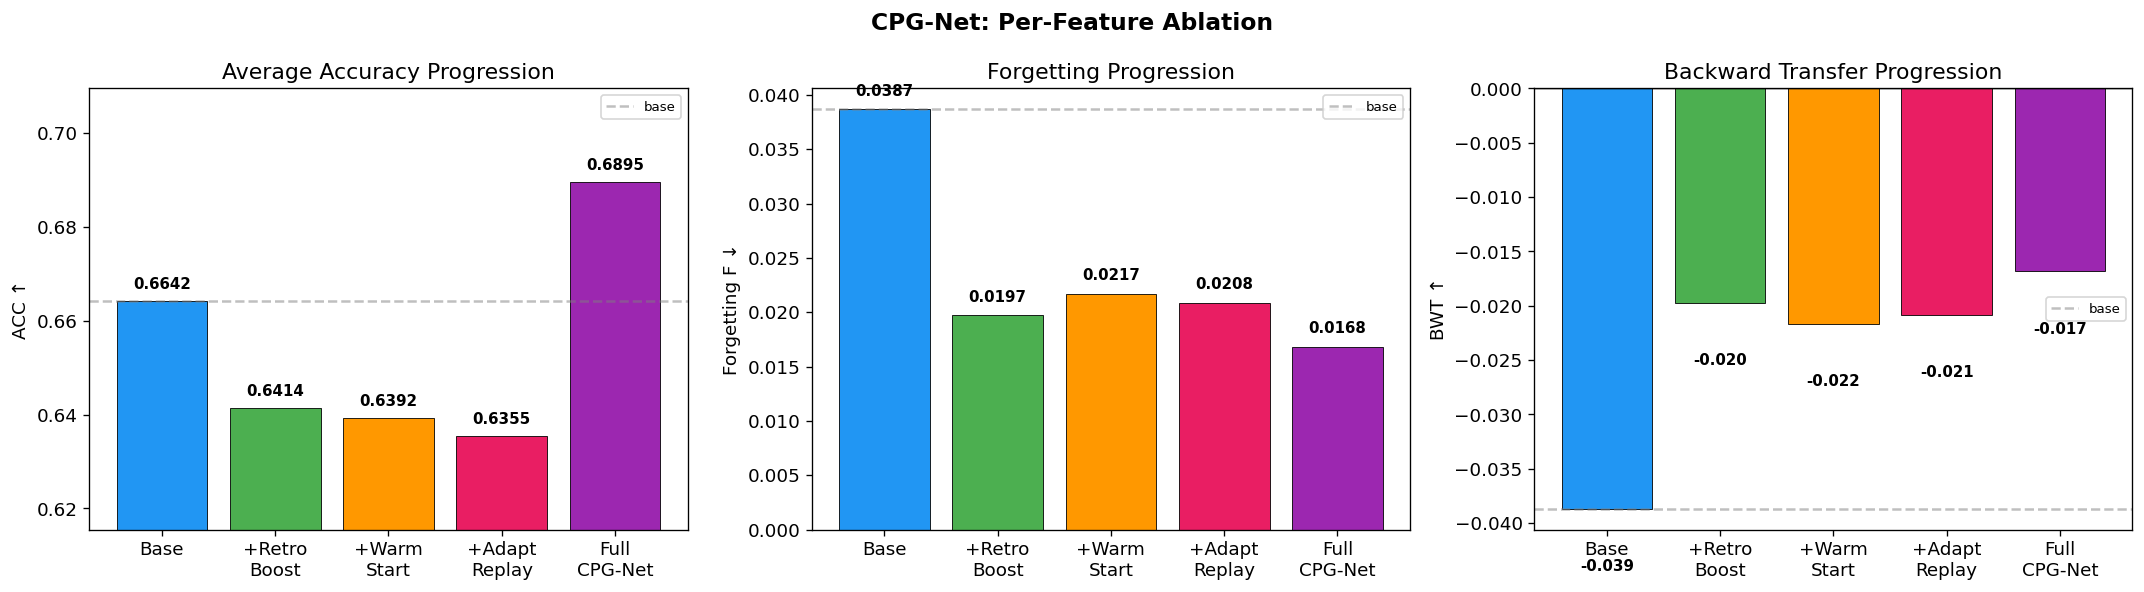

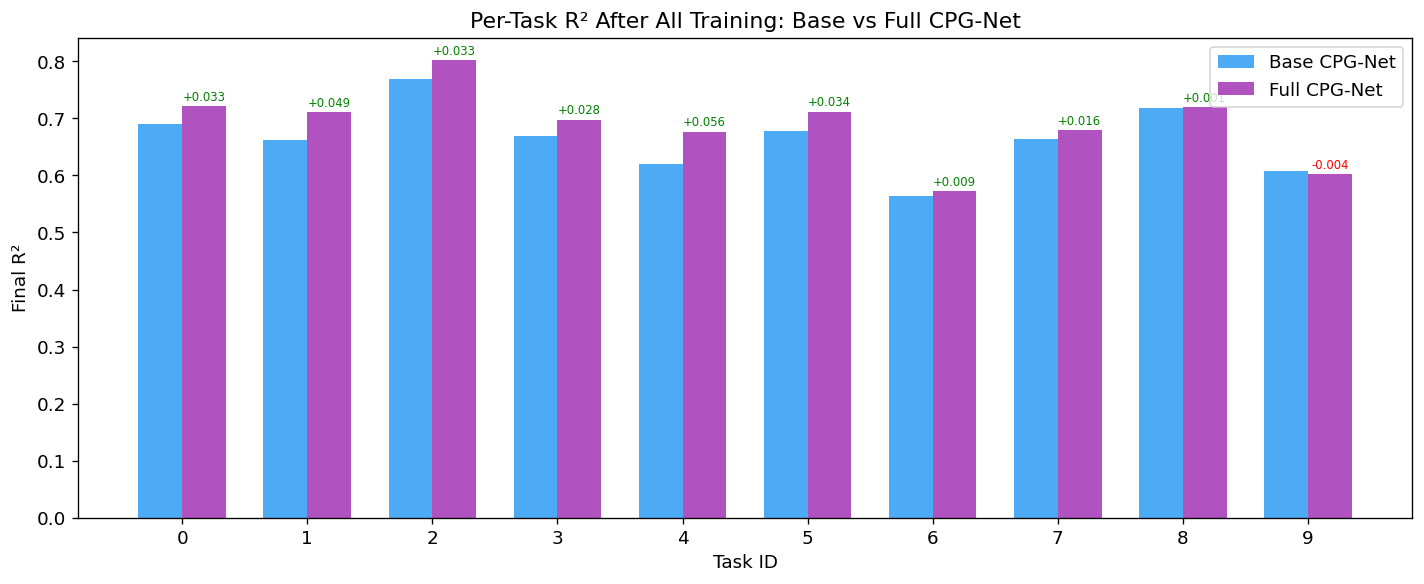


--- Early-Task Forgetting (T0, T1) ---
  T0: Base peak=0.772 final=0.689 drop=0.082  |  Full peak=0.768 final=0.722 drop=0.046
  T1: Base peak=0.741 final=0.663 drop=0.079  |  Full peak=0.748 final=0.712 drop=0.037

Done! Results saved to /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp07_cpg_net


In [8]:
# ================================================================
# Per-Feature Analysis & Visualization
# ================================================================

import matplotlib.pyplot as plt
import numpy as np

config_names = list(improvement_results.keys())
acc_vals = [improvement_results[n]['ACC'] for n in config_names]
f_vals   = [improvement_results[n]['F'] for n in config_names]
bwt_vals = [improvement_results[n]['BWT'] for n in config_names]
fwt_vals = [improvement_results[n]['FWT'] for n in config_names]
r2_vals  = [improvement_results[n]['overall_r2'] for n in config_names]

# --- 1. Summary table ---
print('='*90)
print(f'{"Configuration":<35} {"ACC":>7} {"F":>7} {"BWT":>7} {"FWT":>7} {"R²":>7} {"Mem":>7}')
print('-'*90)
for n in config_names:
    r = improvement_results[n]
    print(f'{n:<35} {r["ACC"]:>7.4f} {r["F"]:>7.4f} {r["BWT"]:>+7.3f} {r["FWT"]:>+7.3f} '
          f'{r["overall_r2"]:>7.3f} {r["memory_mb"]:>6.2f}')
print('='*90)

# --- 2. Delta analysis (per-feature contribution) ---
print('\n--- Per-Feature Delta (incremental contribution) ---')
for i in range(1, len(config_names)):
    prev, curr = config_names[i-1], config_names[i]
    d_acc = improvement_results[curr]['ACC'] - improvement_results[prev]['ACC']
    d_f   = improvement_results[curr]['F']   - improvement_results[prev]['F']
    d_bwt = improvement_results[curr]['BWT'] - improvement_results[prev]['BWT']
    print(f'  {curr:<40} ΔACC={d_acc:>+.4f}  ΔF={d_f:>+.4f}  ΔBWT={d_bwt:>+.4f}')

total_gain = improvement_results[config_names[-1]]['ACC'] - improvement_results[config_names[0]]['ACC']
print(f'  {"Total Base→Full":<40} ΔACC={total_gain:>+.4f}')

# --- 3. Bar chart: ACC progression ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short_names = ['Base', '+Retro\nBoost', '+Warm\nStart', '+Adapt\nReplay', 'Full\nCPG-Net']

# ACC
colors_acc = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
bars = axes[0].bar(short_names, acc_vals, color=colors_acc, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('ACC ↑')
axes[0].set_title('Average Accuracy Progression')
axes[0].set_ylim(min(acc_vals) - 0.02, max(acc_vals) + 0.02)
axes[0].axhline(y=acc_vals[0], ls='--', color='gray', alpha=0.5, label='base')
axes[0].legend(fontsize=8)

# Forgetting
bars = axes[1].bar(short_names, f_vals, color=colors_acc, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, f_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Forgetting F ↓')
axes[1].set_title('Forgetting Progression')
axes[1].axhline(y=f_vals[0], ls='--', color='gray', alpha=0.5, label='base')
axes[1].legend(fontsize=8)

# BWT
bars = axes[2].bar(short_names, bwt_vals, color=colors_acc, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, bwt_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.002 if val >= 0 else -0.006),
                f'{val:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_ylabel('BWT ↑')
axes[2].set_title('Backward Transfer Progression')
axes[2].axhline(y=0, ls='-', color='black', alpha=0.3)
axes[2].axhline(y=bwt_vals[0], ls='--', color='gray', alpha=0.5, label='base')
axes[2].legend(fontsize=8)

fig.suptitle('CPG-Net: Per-Feature Ablation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cpg_net_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 4. R² evolution per task: Base vs Full CPG-Net ---
fig, ax = plt.subplots(figsize=(12, 5))
base_r2 = np.array(improvement_results[config_names[0]]['metrics'].R)
full_r2 = np.array(improvement_results[config_names[-1]]['metrics'].R)
n_tasks_done = base_r2.shape[0]
final_r2_base = [base_r2[-1, t] for t in range(n_tasks_done)]
final_r2_full = [full_r2[-1, t] for t in range(n_tasks_done)]
x = np.arange(n_tasks_done)
w = 0.35
ax.bar(x - w/2, final_r2_base, w, label='Base CPG-Net', color='#2196F3', alpha=0.8)
ax.bar(x + w/2, final_r2_full, w, label='Full CPG-Net', color='#9C27B0', alpha=0.8)
for i in range(n_tasks_done):
    delta = final_r2_full[i] - final_r2_base[i]
    ax.annotate(f'{delta:+.3f}', (x[i] + w/2, final_r2_full[i] + 0.01),
               ha='center', fontsize=7, color='green' if delta > 0 else 'red')
ax.set_xlabel('Task ID')
ax.set_ylabel('Final R²')
ax.set_title('Per-Task R² After All Training: Base vs Full CPG-Net')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cpg_net_base_vs_full_per_task_r2.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 5. Early-task forgetting comparison ---
print('\n--- Early-Task Forgetting (T0, T1) ---')
for tid in [0, 1]:
    base_peak = max(base_r2[tid:, tid])
    base_final = base_r2[-1, tid]
    full_peak = max(full_r2[tid:, tid])
    full_final = full_r2[-1, tid]
    print(f'  T{tid}: Base peak={base_peak:.3f} final={base_final:.3f} drop={base_peak-base_final:.3f}'
          f'  |  Full peak={full_peak:.3f} final={full_final:.3f} drop={full_peak-full_final:.3f}')

print('\nDone! Results saved to', RESULTS_DIR)

In [9]:
# --- Naive Fine-Tune ---
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('='*60)
print('  Running: Naive Fine-Tune')
print('='*60)
learner = NaiveFineTune(make_model(), lr=LR, device=DEVICE)
res_naive = run_strategy('Naive Fine-Tune', learner, task_list)
print(f'\n  ACC={res_naive["ACC"]:.4f}  F={res_naive["F"]:.4f}  '
      f'BWT={res_naive["BWT"]:+.4f}  FWT={res_naive["FWT"]:+.4f}  '
      f'Mem={res_naive["memory_mb"]:.2f}MB  Time={res_naive["time"]:.0f}s')


  Running: Naive Fine-Tune
  [Naive Fine-Tune] Task 0/9 (p100)
  [Naive Fine-Tune] Task 1/9 (p101)
  [Naive Fine-Tune] Task 2/9 (p102)
  [Naive Fine-Tune] Task 3/9 (p103)
  [Naive Fine-Tune] Task 4/9 (p104)
  [Naive Fine-Tune] Task 5/9 (p105)
  [Naive Fine-Tune] Task 6/9 (p106)
  [Naive Fine-Tune] Task 7/9 (p107)
  [Naive Fine-Tune] Task 8/9 (p108)
  [Naive Fine-Tune] Task 9/9 (p109)

  ACC=-0.4695  F=1.3549  BWT=-1.3549  FWT=-0.3003  Mem=0.00MB  Time=99s


In [10]:
# --- Joint Training ---
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('='*60)
print('  Running: Joint Training')
print('='*60)
learner = JointTraining(make_model(), lr=LR, device=DEVICE)
res_joint = run_strategy('Joint Training', learner, task_list)
print(f'\n  ACC={res_joint["ACC"]:.4f}  F={res_joint["F"]:.4f}  '
      f'BWT={res_joint["BWT"]:+.4f}  FWT={res_joint["FWT"]:+.4f}  '
      f'Mem={res_joint["memory_mb"]:.2f}MB  Time={res_joint["time"]:.0f}s')


  Running: Joint Training
  [Joint Training] Task 0/9 (p100)
  [Joint Training] Task 1/9 (p101)
  [Joint Training] Task 2/9 (p102)
  [Joint Training] Task 3/9 (p103)
  [Joint Training] Task 4/9 (p104)
  [Joint Training] Task 5/9 (p105)
  [Joint Training] Task 6/9 (p106)
  [Joint Training] Task 7/9 (p107)
  [Joint Training] Task 8/9 (p108)


KeyboardInterrupt: 

In [ ]:
# --- Online EWC ---
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('='*60)
print('  Running: Online EWC')
print('='*60)
learner = EWC(make_model(), lr=LR, device=DEVICE,
              ewc_lambda=EWC_LAMBDA, fisher_samples=EWC_FISHER_N,
              online=True, gamma=OEWC_GAMMA)
res_ewc = run_strategy('Online EWC', learner, task_list)
print(f'\n  ACC={res_ewc["ACC"]:.4f}  F={res_ewc["F"]:.4f}  '
      f'BWT={res_ewc["BWT"]:+.4f}  FWT={res_ewc["FWT"]:+.4f}  '
      f'Mem={res_ewc["memory_mb"]:.2f}MB  Time={res_ewc["time"]:.0f}s')


  Running: Online EWC
  [Online EWC] Task 0/9 (p100)
  [Online EWC] Task 1/9 (p101)
  [Online EWC] Task 2/9 (p102)
  [Online EWC] Task 3/9 (p103)
  [Online EWC] Task 4/9 (p104)
  [Online EWC] Task 5/9 (p105)
  [Online EWC] Task 6/9 (p106)
  [Online EWC] Task 7/9 (p107)
  [Online EWC] Task 8/9 (p108)
  [Online EWC] Task 9/9 (p109)

  ACC=0.4152  F=0.2105  BWT=-0.2105  FWT=+0.0833  Mem=0.54MB  Time=124s


In [ ]:
# --- A-GEM ---
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('='*60)
print('  Running: A-GEM')
print('='*60)
learner = AGEM(make_model(), lr=LR, device=DEVICE, mem_per_task=AGEM_MEM)
res_agem = run_strategy('A-GEM', learner, task_list)
print(f'\n  ACC={res_agem["ACC"]:.4f}  F={res_agem["F"]:.4f}  '
      f'BWT={res_agem["BWT"]:+.4f}  FWT={res_agem["FWT"]:+.4f}  '
      f'Mem={res_agem["memory_mb"]:.2f}MB  Time={res_agem["time"]:.0f}s')


  Running: A-GEM
  [A-GEM] Task 0/9 (p100)
  [A-GEM] Task 1/9 (p101)
  [A-GEM] Task 2/9 (p102)
  [A-GEM] Task 3/9 (p103)
  [A-GEM] Task 4/9 (p104)
  [A-GEM] Task 5/9 (p105)
  [A-GEM] Task 6/9 (p106)
  [A-GEM] Task 7/9 (p107)
  [A-GEM] Task 8/9 (p108)
  [A-GEM] Task 9/9 (p109)

  ACC=0.4196  F=0.3761  BWT=-0.3761  FWT=-0.0488  Mem=0.18MB  Time=139s


In [ ]:
# --- DER++ ---
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('='*60)
print('  Running: DER++')
print('='*60)
learner = DERPlusPlus(make_model(), lr=LR, device=DEVICE, buffer_size=DER_BUFFER)
res_derpp = run_strategy('DER++', learner, task_list)
print(f'\n  ACC={res_derpp["ACC"]:.4f}  F={res_derpp["F"]:.4f}  '
      f'BWT={res_derpp["BWT"]:+.4f}  FWT={res_derpp["FWT"]:+.4f}  '
      f'Mem={res_derpp["memory_mb"]:.2f}MB  Time={res_derpp["time"]:.0f}s')


  Running: DER++
  [DER++] Task 0/9 (p100)
  [DER++] Task 1/9 (p101)
  [DER++] Task 2/9 (p102)
  [DER++] Task 3/9 (p103)
  [DER++] Task 4/9 (p104)
  [DER++] Task 5/9 (p105)
  [DER++] Task 6/9 (p106)
  [DER++] Task 7/9 (p107)
  [DER++] Task 8/9 (p108)
  [DER++] Task 9/9 (p109)

  ACC=0.6120  F=0.1480  BWT=-0.1480  FWT=+0.1720  Mem=0.92MB  Time=161s


In [ ]:
# --- CPG-Net (ours) -- NOVEL METHOD ---
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print('='*60)
print('  Running: CPG-Net (ours)')
print('='*60)
model_v3 = make_cpg_v3_model(use_multi_head=True, head_blend=0.3).to(DEVICE)
learner_v3 = CPGNetLearnerV3(
    model_v3, lr=LR, device=DEVICE,
    buffer_size=CPG_BUFFER_SIZE,
    replay_alpha=CPG_REPLAY_ALPHA, replay_beta=CPG_REPLAY_BETA,
    importance_lambda=CPG_IMPORTANCE_LAM,
    fisher_samples=CPG_FISHER_N,
    film_lr=CPG_FILM_LR,
    use_retro_boost=True, use_warm_start=True, use_adaptive_replay=True,
)
res_cpg = run_strategy_v3('CPG-Net (ours)', learner_v3, task_list)
print(f'\n  ACC={res_cpg["ACC"]:.4f}  F={res_cpg["F"]:.4f}  '
      f'BWT={res_cpg["BWT"]:+.4f}  FWT={res_cpg["FWT"]:+.4f}  '
      f'R2={res_cpg["overall_r2"]:.4f}  Mem={res_cpg["memory_mb"]:.2f}MB  T={res_cpg["time"]:.1f}s')

  Running: CPG-Net v3 (ours)
  [CPG-Net v3 (ours)] Task 0/9 (p100)
  [CPG-Net v3 (ours)] Task 1/9 (p101)
  [CPG-Net v3 (ours)] Task 2/9 (p102)
  [CPG-Net v3 (ours)] Task 3/9 (p103)
  [CPG-Net v3 (ours)] Task 4/9 (p104)
  [CPG-Net v3 (ours)] Task 5/9 (p105)
  [CPG-Net v3 (ours)] Task 6/9 (p106)
  [CPG-Net v3 (ours)] Task 7/9 (p107)
  [CPG-Net v3 (ours)] Task 8/9 (p108)
  [CPG-Net v3 (ours)] Task 9/9 (p109)

  ACC=0.6895  F=0.0168  BWT=-0.0168  FWT=+0.1175  R2=0.6832  Mem=1.28MB  T=564.5s


In [ ]:
# Collect all results
all_results = {
    'Naive Fine-Tune': res_naive,
    'Joint Training':  res_joint,
    'Online EWC':      res_ewc,
    'A-GEM':           res_agem,
    'DER++':           res_derpp,
    'CPG-Net (ours)':  res_cpg,
}

# ================================================================
# Results Table -- Ranked by ACC
# ================================================================
print('='*120)
print('EXPERIMENT 7 -- CPG-Net vs ALL BASELINES (Ranked by ACC)')
print('='*120)
print(f'{"Rank":>4s}  {"Strategy":<25s}  {"ACC":>8s}  {"F":>8s}  {"BWT":>8s}  '
      f'{"FWT":>8s}  {"Ovrl R2":>8s}  {"Mem(MB)":>8s}  {"Time(s)":>8s}')
print('-' * 115)

ranked = sorted(all_results.items(), key=lambda x: x[1]['ACC'], reverse=True)

for rank, (name, d) in enumerate(ranked, 1):
    marker = ' ***' if 'CPG-Net' in name else ''
    print(f'{rank:4d}  {name:<25s}  {d["ACC"]:8.4f}  {d["F"]:8.4f}  {d["BWT"]:+8.4f}  '
          f'{d["FWT"]:+8.4f}  {d["overall_r2"]:8.4f}  {d["memory_mb"]:8.2f}  {d["time"]:7.0f}s{marker}')

# Gap analysis
print(f'\n{"="*120}')
print('GAP ANALYSIS')
print(f'{"="*120}')

cpg = all_results['CPG-Net (ours)']
dp = all_results['DER++']
jt = all_results['Joint Training']

print(f'  CPG-Net vs DER++ (best standard replay CL):')
print(f'    ACC improvement:         {cpg["ACC"] - dp["ACC"]:+.4f}')
print(f'    Forgetting reduction:    {dp["F"] - cpg["F"]:+.4f} (positive = less forgetting)')
print(f'    BWT improvement:         {cpg["BWT"] - dp["BWT"]:+.4f}')
print(f'    FWT improvement:         {cpg["FWT"] - dp["FWT"]:+.4f}')

print(f'\n  CPG-Net vs Joint Training (upper bound):')
print(f'    ACC gap:                 {cpg["ACC"] - jt["ACC"]:+.4f}')
gap_closed = (cpg["ACC"] - dp["ACC"]) / max(jt["ACC"] - dp["ACC"], 1e-8) * 100
print(f'    Gap closed (vs DER++):   {gap_closed:.1f}%')

# Save
save_data = {}
for k, v in all_results.items():
    save_data[k] = {kk: vv for kk, vv in v.items()
                    if kk not in ('metrics', 'summary')}
    save_data[k]['summary'] = v['summary']
with open(f'{RESULTS_DIR}/full_results.json', 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f'\nResults saved to {RESULTS_DIR}/full_results.json')

EXPERIMENT 7 -- CPG-Net v2/v3 vs ALL BASELINES (Ranked by ACC)
Rank  Strategy                        ACC         F       BWT       FWT   Ovrl R2   Mem(MB)   Time(s)
-----------------------------------------------------------------------------------------------------------------------------
   1  CPG-Net v3 (ours)            0.6895    0.0168   -0.0168   +0.1175    0.6832      1.28      565s ***
   2  CPG-Net v2 (ours)            0.6642    0.0387   -0.0387   +0.1290    0.6561      1.22      381s ***
   3  Joint Training               0.6442    0.0365   -0.0044   +0.0130    0.6555   1664.16     8105s
   4  DER-SA                       0.6185    0.1433   -0.1433   +0.1448    0.6107     10.68      205s
   5  DER++                        0.6120    0.1480   -0.1480   +0.1720    0.6013      0.92      161s
   6  A-GEM                        0.4196    0.3761   -0.3761   -0.0488    0.4015      0.18      139s
   7  Online EWC                   0.4152    0.2105   -0.2105   +0.0833    0.4026      0.

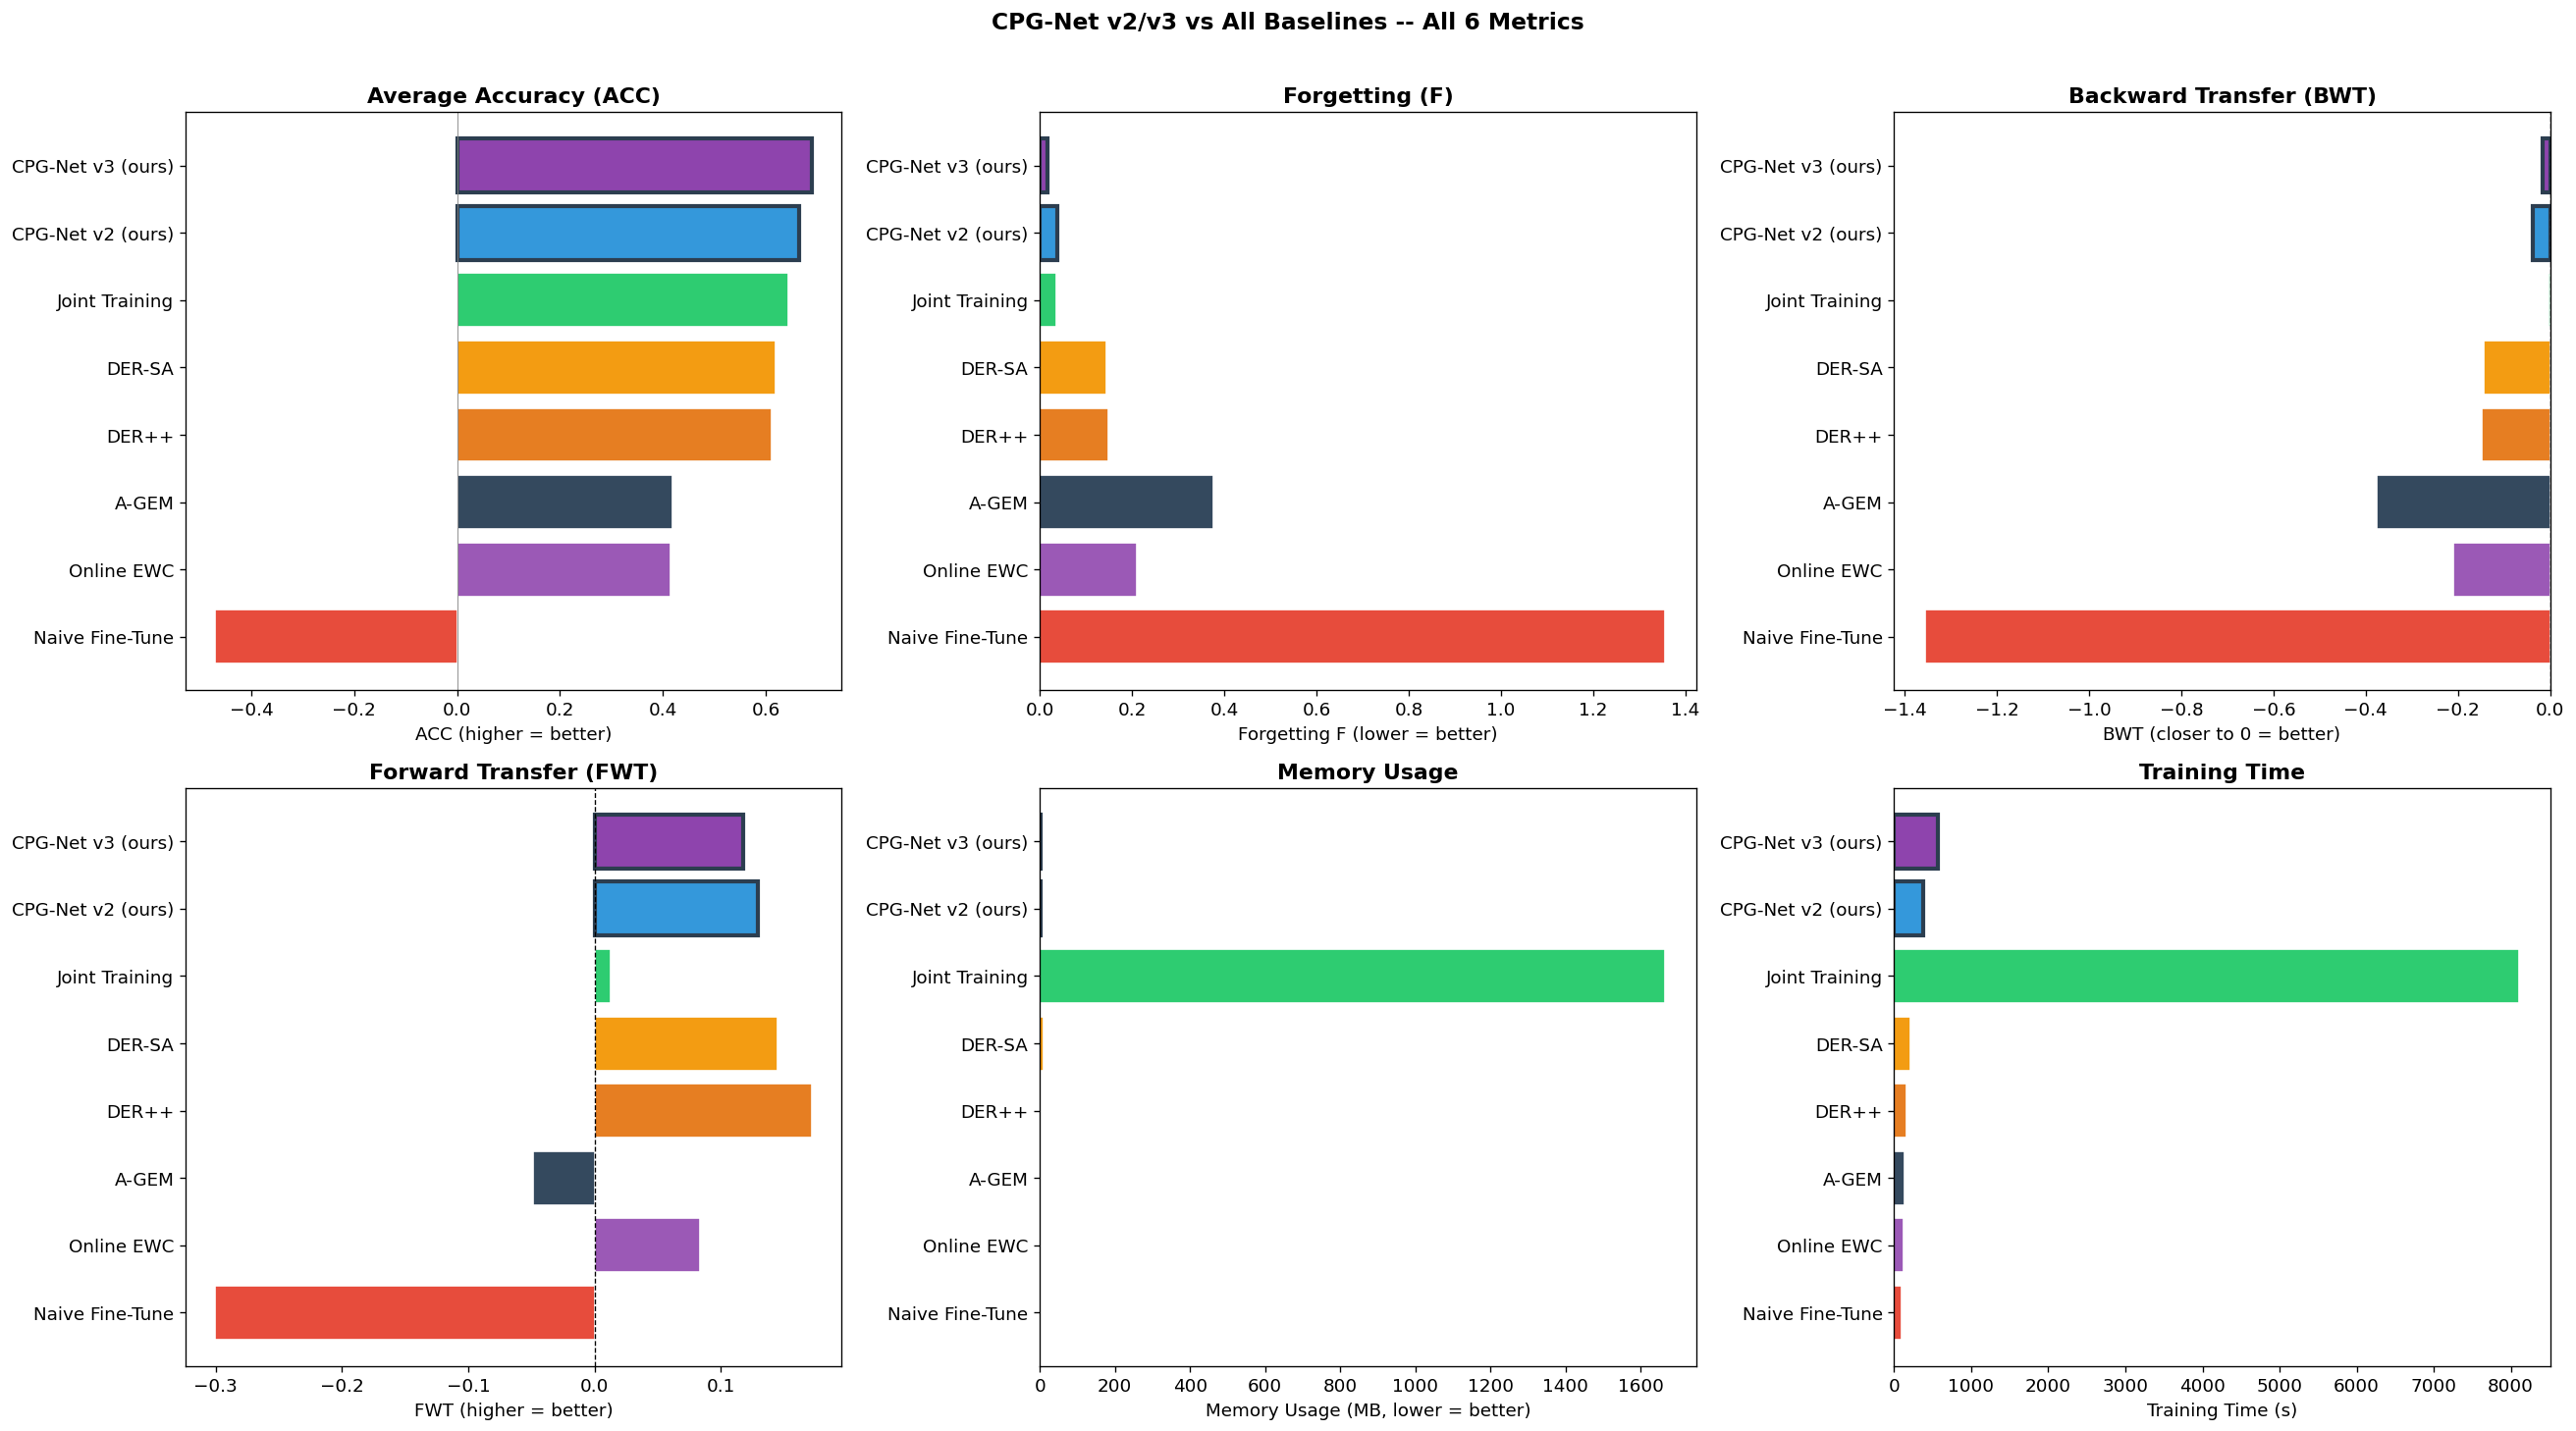

In [ ]:
# Visualization: All 6 Metrics

colors = {
    'Naive Fine-Tune': '#e74c3c', 'Joint Training': '#2ecc71',
    'DER++': '#e67e22', 'Online EWC': '#9b59b6', 'A-GEM': '#34495e',
    'CPG-Net (ours)': '#3498db',
}

ranked_names = [n for n, _ in ranked]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# --- ACC ---
ax = axes[0, 0]
vals = [all_results[n]['ACC'] for n in ranked_names]
bars = ax.barh(ranked_names[::-1], vals[::-1],
               color=[colors.get(n, '#888') for n in ranked_names[::-1]], edgecolor='white')
for bar, name in zip(bars, ranked_names[::-1]):
    if 'CPG-Net' in name:
        bar.set_edgecolor('#2c3e50'); bar.set_linewidth(2.5)
ax.set_xlabel('ACC (higher = better)')
ax.set_title('Average Accuracy (ACC)', fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.5)

# --- Forgetting ---
ax = axes[0, 1]
vals = [all_results[n]['F'] for n in ranked_names]
bars = ax.barh(ranked_names[::-1], vals[::-1],
               color=[colors.get(n, '#888') for n in ranked_names[::-1]], edgecolor='white')
for bar, name in zip(bars, ranked_names[::-1]):
    if 'CPG-Net' in name:
        bar.set_edgecolor('#2c3e50'); bar.set_linewidth(2.5)
ax.set_xlabel('Forgetting F (lower = better)')
ax.set_title('Forgetting (F)', fontweight='bold')

# --- BWT ---
ax = axes[0, 2]
vals = [all_results[n]['BWT'] for n in ranked_names]
bars = ax.barh(ranked_names[::-1], vals[::-1],
               color=[colors.get(n, '#888') for n in ranked_names[::-1]], edgecolor='white')
for bar, name in zip(bars, ranked_names[::-1]):
    if 'CPG-Net' in name:
        bar.set_edgecolor('#2c3e50'); bar.set_linewidth(2.5)
ax.set_xlabel('BWT (closer to 0 = better)')
ax.set_title('Backward Transfer (BWT)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# --- FWT ---
ax = axes[1, 0]
vals = [all_results[n]['FWT'] for n in ranked_names]
bars = ax.barh(ranked_names[::-1], vals[::-1],
               color=[colors.get(n, '#888') for n in ranked_names[::-1]], edgecolor='white')
for bar, name in zip(bars, ranked_names[::-1]):
    if 'CPG-Net' in name:
        bar.set_edgecolor('#2c3e50'); bar.set_linewidth(2.5)
ax.set_xlabel('FWT (higher = better)')
ax.set_title('Forward Transfer (FWT)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# --- Memory ---
ax = axes[1, 1]
vals = [all_results[n]['memory_mb'] for n in ranked_names]
bars = ax.barh(ranked_names[::-1], vals[::-1],
               color=[colors.get(n, '#888') for n in ranked_names[::-1]], edgecolor='white')
for bar, name in zip(bars, ranked_names[::-1]):
    if 'CPG-Net' in name:
        bar.set_edgecolor('#2c3e50'); bar.set_linewidth(2.5)
ax.set_xlabel('Memory Usage (MB, lower = better)')
ax.set_title('Memory Usage', fontweight='bold')

# --- Time ---
ax = axes[1, 2]
vals = [all_results[n]['time'] for n in ranked_names]
bars = ax.barh(ranked_names[::-1], vals[::-1],
               color=[colors.get(n, '#888') for n in ranked_names[::-1]], edgecolor='white')
for bar, name in zip(bars, ranked_names[::-1]):
    if 'CPG-Net' in name:
        bar.set_edgecolor('#2c3e50'); bar.set_linewidth(2.5)
ax.set_xlabel('Training Time (s)')
ax.set_title('Training Time', fontweight='bold')

plt.suptitle('CPG-Net vs All Baselines -- All 6 Metrics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

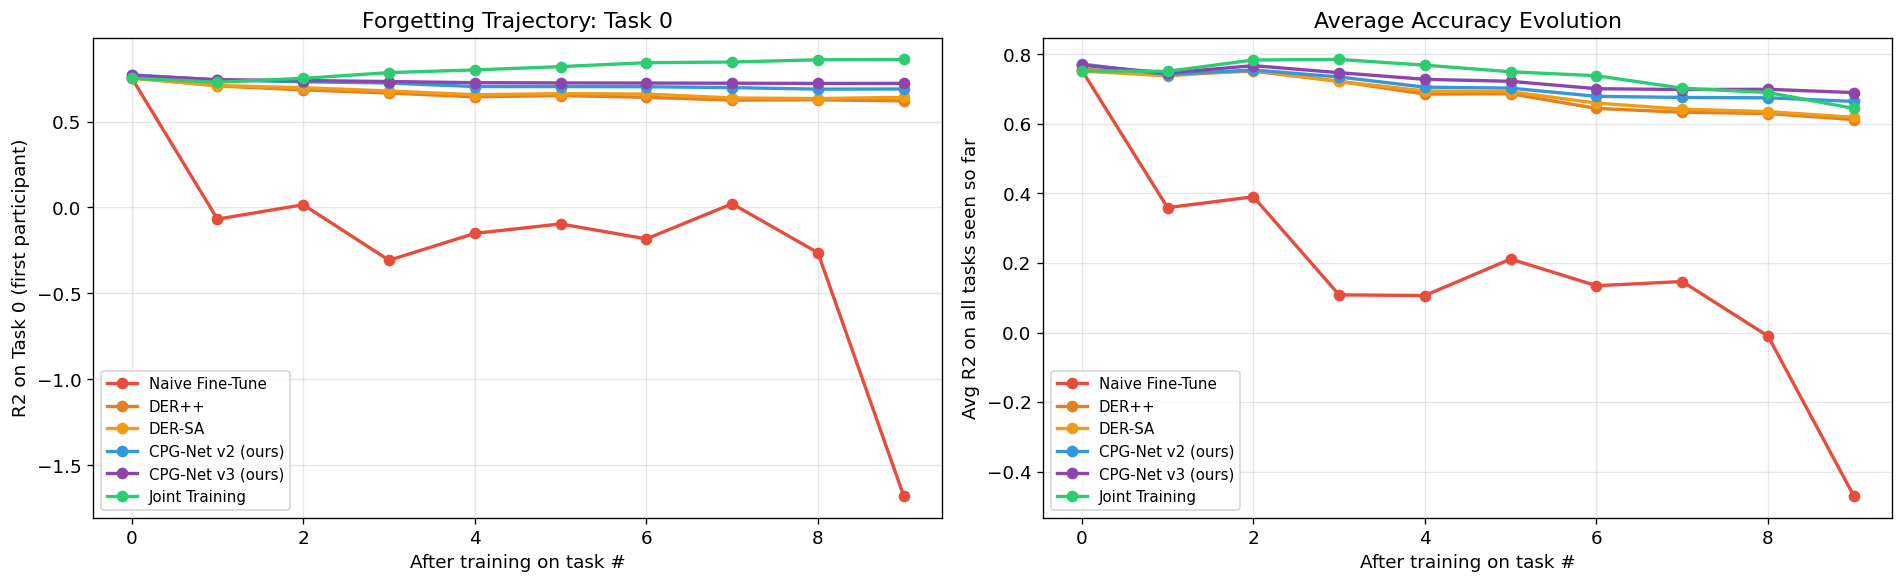

In [ ]:
# R2 evolution: forgetting trajectory + average accuracy over time

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

focus_strats = ['Naive Fine-Tune', 'DER++', 'CPG-Net (ours)', 'Joint Training']

# Plot 1: Task 0 R2 over time
ax = axes[0]
for name in focus_strats:
    if name in all_results and 'summary' in all_results[name]:
        r2_mat = all_results[name]['summary']['r2_matrix']
        task0_r2 = [r2_mat[i][0] for i in range(len(r2_mat)) if len(r2_mat[i]) > 0]
        ax.plot(range(len(task0_r2)), task0_r2, 'o-', label=name,
                color=colors.get(name, '#888'), linewidth=2, markersize=6)
ax.set_xlabel('After training on task #')
ax.set_ylabel('R2 on Task 0 (first participant)')
ax.set_title('Forgetting Trajectory: Task 0')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Average R2 across all seen tasks
ax = axes[1]
for name in focus_strats:
    if name in all_results and 'summary' in all_results[name]:
        r2_mat = all_results[name]['summary']['r2_matrix']
        avg_r2 = []
        for i in range(len(r2_mat)):
            if r2_mat[i]:
                avg_r2.append(np.mean(r2_mat[i][:i+1]))
        ax.plot(range(len(avg_r2)), avg_r2, 'o-', label=name,
                color=colors.get(name, '#888'), linewidth=2, markersize=6)
ax.set_xlabel('After training on task #')
ax.set_ylabel('Avg R2 on all tasks seen so far')
ax.set_title('Average Accuracy Evolution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/r2_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Overfitting & Learning Anomaly Diagnostics (CPG-Net)

We re-train CPG-Net while recording **train loss** and **val loss** per epoch for every task.
This checks for:
- **Overfitting**: train loss drops but val loss rises
- **Loss spikes**: sudden loss explosions during training
- **Non-convergence**: model not improving within patience window

Training CPG-Net v3 with loss diagnostics...
  Task 0 (p100)  [50 epochs, train=0.2192, val=0.1981]
  Task 1 (p101)  [50 epochs, train=0.5506, val=0.2808]
  Task 2 (p102)  [48 epochs, train=0.3113, val=0.1054]
  Task 3 (p103)  [50 epochs, train=0.5631, val=0.2900]
  Task 4 (p104)  [50 epochs, train=0.8605, val=0.5118]
  Task 5 (p105)  [50 epochs, train=0.5126, val=0.2502]
  Task 6 (p106)  [50 epochs, train=0.6498, val=0.3515]
  Task 7 (p107)  [50 epochs, train=0.6437, val=0.3394]
  Task 8 (p108)  [50 epochs, train=0.7883, val=0.3774]
  Task 9 (p109)  [50 epochs, train=0.7758, val=0.4209]

Done! Analyzing results...


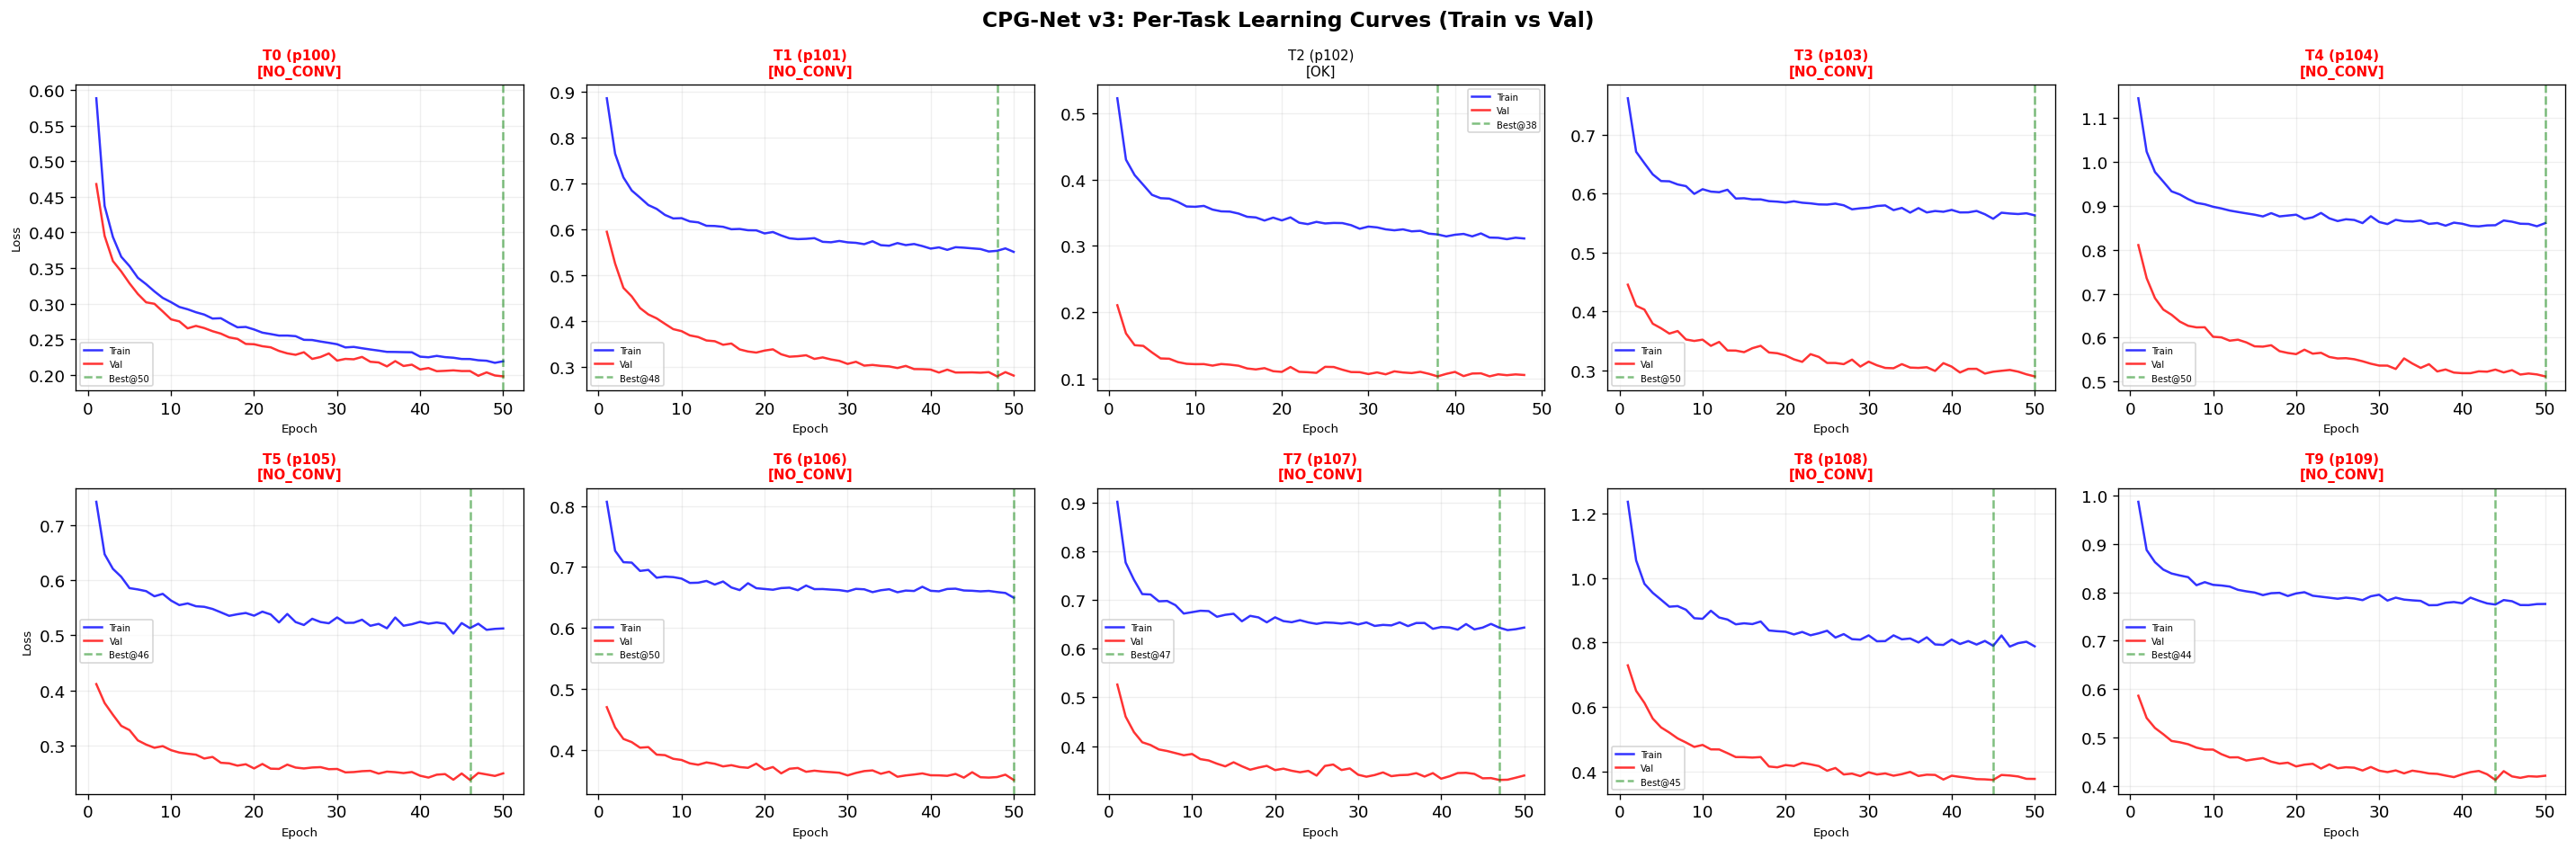


OVERFITTING & ANOMALY REPORT -- CPG-Net v3
Task   PID      Status       Epochs   Train↓     Val↓  BestVal  ValRise% T/V Ratio
---------------------------------------------------------------------------------------------------------
T0     p100     NO_CONV          50   0.2192   0.1981   0.1981     +0.0%     1.107
T1     p101     NO_CONV          50   0.5506   0.2808   0.2791     +0.6%     1.961
T2     p102     OK               48   0.3113   0.1054   0.1033     +2.1%     2.954
T3     p103     NO_CONV          50   0.5631   0.2900   0.2900     +0.0%     1.942
T4     p104     NO_CONV          50   0.8605   0.5118   0.5118     +0.0%     1.681
T5     p105     NO_CONV          50   0.5126   0.2502   0.2383     +5.0%     2.049
T6     p106     NO_CONV          50   0.6498   0.3515   0.3515     +0.0%     1.848
T7     p107     NO_CONV          50   0.6437   0.3394   0.3303     +2.7%     1.897
T8     p108     NO_CONV          50   0.7883   0.3774   0.3742     +0.8%     2.089
T9     p109     NO_C

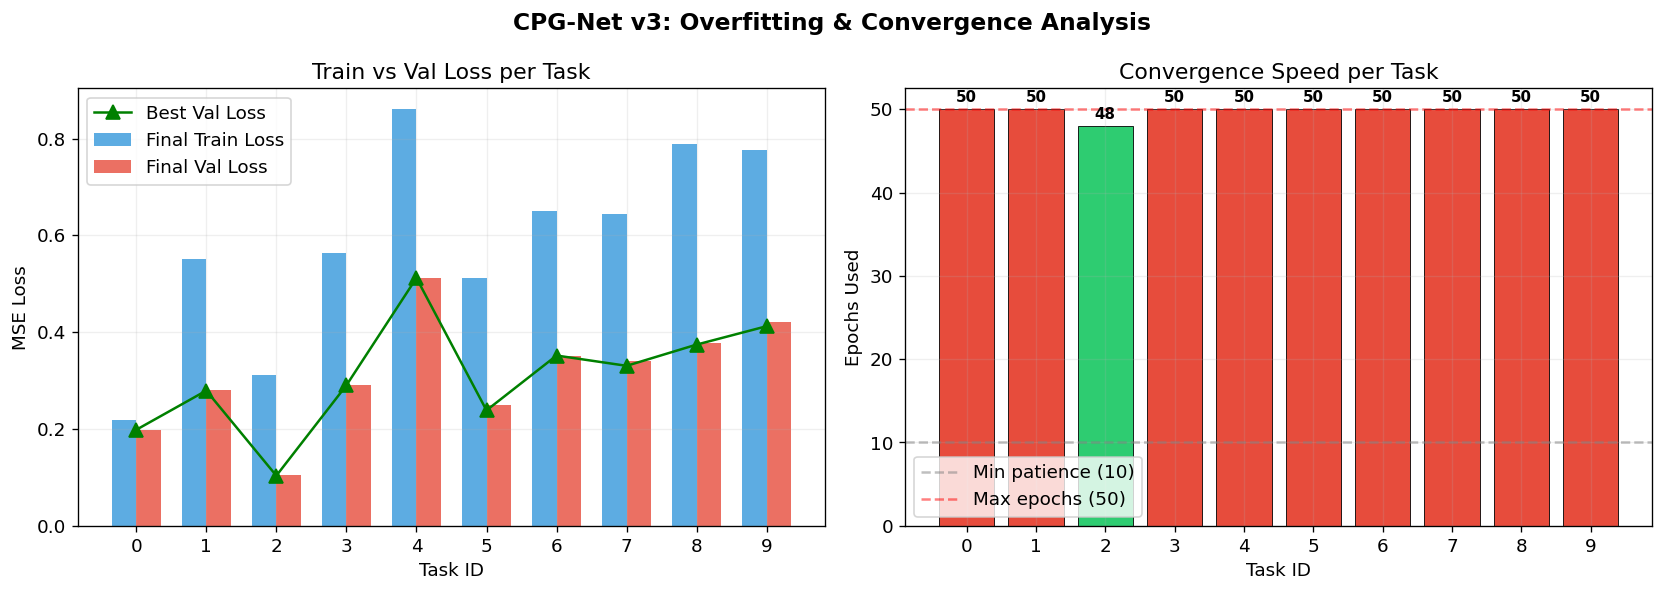

In [ ]:
# ================================================================
# Overfitting & Learning Anomaly Diagnostics for CPG-Net
# ================================================================
# Re-train CPG-Net with per-epoch train/val logging

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

diag_model = make_cpg_v3_model(use_multi_head=True, head_blend=0.3).to(DEVICE)
diag_learner = CPGNetLearnerV3(
    diag_model, lr=LR, device=DEVICE,
    buffer_size=CPG_BUFFER_SIZE,
    replay_alpha=CPG_REPLAY_ALPHA, replay_beta=CPG_REPLAY_BETA,
    importance_lambda=CPG_IMPORTANCE_LAM, fisher_samples=CPG_FISHER_N,
    film_lr=CPG_FILM_LR,
    use_retro_boost=True, use_warm_start=True, use_adaptive_replay=True,
)

# Storage for per-task learning curves
task_train_losses = {}  # task_id -> [loss_per_epoch]
task_val_losses = {}
task_epochs_used = {}

print('Training CPG-Net with loss diagnostics...')
for task in task_list:
    tid = task.task_id
    print(f'  Task {tid} ({task.participant_id})', end='', flush=True)

    diag_learner._current_task = tid
    diag_learner.on_task_start(tid, task.train_loader(BS))
    diag_learner.model.train()

    train_losses, val_losses = [], []
    best_val, best_state, no_improve = float('inf'), None, 0

    for epoch in range(EPOCHS):
        eloss, nb = 0., 0
        for batch in task.train_loader(BS):
            obs, act = batch[0].to(DEVICE), batch[1].to(DEVICE)
            diag_learner.optimizer.zero_grad()
            loss = diag_learner.compute_loss(obs, act, tid)
            loss.backward()
            nn.utils.clip_grad_norm_(diag_learner.model.parameters(), 1.0)
            diag_learner.optimizer.step()
            eloss += loss.item(); nb += 1
        train_losses.append(eloss / max(nb, 1))

        vl = diag_learner._eval_loss(task.val_loader(BS * 2), tid)
        val_losses.append(vl)

        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(diag_learner.model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break

    if best_state is not None:
        diag_learner.model.load_state_dict(best_state)
    diag_learner.on_task_end(tid, task.train_loader(BS))

    task_train_losses[tid] = train_losses
    task_val_losses[tid] = val_losses
    task_epochs_used[tid] = len(train_losses)
    print(f'  [{len(train_losses)} epochs, train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}]')

print('\nDone! Analyzing results...')

# ================================================================
# Analysis
# ================================================================

# 1. Learning curves per task (2x5 grid)
fig, axes = plt.subplots(2, 5, figsize=(24, 8), sharex=False)
anomaly_flags = []

for tid in range(N_TASKS):
    ax = axes[tid // 5, tid % 5]
    tr = task_train_losses[tid]
    vl = task_val_losses[tid]
    epochs = range(1, len(tr) + 1)

    ax.plot(epochs, tr, 'b-', linewidth=1.5, label='Train', alpha=0.8)
    ax.plot(epochs, vl, 'r-', linewidth=1.5, label='Val', alpha=0.8)

    # Mark best val epoch
    best_epoch = np.argmin(vl)
    ax.axvline(best_epoch + 1, color='green', linestyle='--', alpha=0.5, label=f'Best@{best_epoch+1}')

    # Check overfitting: val loss at end vs at best
    gap_ratio = vl[-1] / max(vl[best_epoch], 1e-8)
    final_train_val_ratio = tr[-1] / max(vl[-1], 1e-8)

    # Flags
    flags = []
    if gap_ratio > 1.15:
        flags.append('OVF')  # val loss diverges >15%
    if len(tr) == EPOCHS:
        flags.append('NO_CONV')  # used max epochs
    # Check for loss spikes (>2x of running mean)
    if len(tr) > 5:
        running_mean = np.convolve(tr, np.ones(3)/3, mode='valid')
        spike_ratio = max(tr[2:]) / max(np.mean(running_mean), 1e-8)
        if spike_ratio > 3.0:
            flags.append('SPIKE')

    flag_str = ','.join(flags) if flags else 'OK'
    anomaly_flags.append((tid, task_list[tid].participant_id, flag_str, len(tr),
                          tr[-1], vl[-1], vl[best_epoch], gap_ratio, final_train_val_ratio))

    title_color = 'red' if flags else 'black'
    ax.set_title(f'T{tid} ({task_list[tid].participant_id})\n[{flag_str}]',
                 fontsize=9, color=title_color, fontweight='bold' if flags else 'normal')
    ax.set_xlabel('Epoch', fontsize=8)
    if tid % 5 == 0:
        ax.set_ylabel('Loss', fontsize=8)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.2)

fig.suptitle('CPG-Net: Per-Task Learning Curves (Train vs Val)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/v3_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Summary table
print('\n' + '='*110)
print('OVERFITTING & ANOMALY REPORT -- CPG-Net')
print('='*110)
print(f'{"Task":<6} {"PID":<8} {"Status":<12} {"Epochs":>6} {"Train↓":>8} {"Val↓":>8} '
      f'{"BestVal":>8} {"ValRise%":>9} {"T/V Ratio":>9}')
print('-'*105)
for tid, pid, flag, n_ep, tl, vl_f, vl_b, gr, tvr in anomaly_flags:
    rise_pct = (gr - 1) * 100
    status_color = flag
    print(f'T{tid:<5} {pid:<8} {flag:<12} {n_ep:>6} {tl:>8.4f} {vl_f:>8.4f} '
          f'{vl_b:>8.4f} {rise_pct:>+8.1f}% {tvr:>9.3f}')

# 3. Overall verdict
n_ovf = sum(1 for _, _, f, *_ in anomaly_flags if 'OVF' in f)
n_spike = sum(1 for _, _, f, *_ in anomaly_flags if 'SPIKE' in f)
n_noconv = sum(1 for _, _, f, *_ in anomaly_flags if 'NO_CONV' in f)
n_ok = sum(1 for _, _, f, *_ in anomaly_flags if f == 'OK')

print(f'\n{"="*70}')
print(f'VERDICT: {n_ok}/{N_TASKS} tasks healthy')
print(f'  Overfitting (val rises >15%): {n_ovf} tasks')
print(f'  Loss spikes (>3x mean):       {n_spike} tasks')
print(f'  No convergence (max epochs):  {n_noconv} tasks')
avg_epochs = np.mean([e for _, _, _, e, *_ in anomaly_flags])
avg_tvr = np.mean([tvr for _, _, _, _, _, _, _, _, tvr in anomaly_flags])
print(f'  Avg epochs used: {avg_epochs:.1f}/{EPOCHS}')
print(f'  Avg train/val loss ratio: {avg_tvr:.3f} (1.0=perfect, <0.8=underfitting, >1.2=leaking)')
print(f'{"="*70}')

# 4. Train-Val gap evolution across tasks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tids = list(range(N_TASKS))
final_train = [task_train_losses[t][-1] for t in tids]
final_val = [task_val_losses[t][-1] for t in tids]
best_vals = [min(task_val_losses[t]) for t in tids]
epochs_used = [task_epochs_used[t] for t in tids]

# Left: train vs val final loss
x = np.arange(N_TASKS)
w = 0.35
ax1.bar(x - w/2, final_train, w, label='Final Train Loss', color='#3498db', alpha=0.8)
ax1.bar(x + w/2, final_val, w, label='Final Val Loss', color='#e74c3c', alpha=0.8)
ax1.plot(x, best_vals, 'g^-', label='Best Val Loss', markersize=8, linewidth=1.5)
ax1.set_xlabel('Task ID')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Train vs Val Loss per Task')
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.2)

# Right: epochs used per task
bars = ax2.bar(x, epochs_used, color=['#2ecc71' if e < EPOCHS else '#e74c3c' for e in epochs_used],
               edgecolor='black', linewidth=0.5)
for bar, e in zip(bars, epochs_used):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(e), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(y=PATIENCE, ls='--', color='gray', alpha=0.5, label=f'Min patience ({PATIENCE})')
ax2.axhline(y=EPOCHS, ls='--', color='red', alpha=0.5, label=f'Max epochs ({EPOCHS})')
ax2.set_xlabel('Task ID')
ax2.set_ylabel('Epochs Used')
ax2.set_title('Convergence Speed per Task')
ax2.set_xticks(x)
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle('CPG-Net: Overfitting & Convergence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/v3_overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()